In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original training shape:", x_train.shape)
print("Original test shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original training shape: (60000, 28, 28)
Original test shape: (10000, 28, 28)


In [ ]:
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

print("Training:", x_train.shape)
print("Testing :", x_test.shape)

Training: (10000, 28, 28)
Testing : (2000, 28, 28)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


In [ ]:
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)

Training shape: (10000, 28, 28, 1)
Testing shape : (2000, 28, 28, 1)


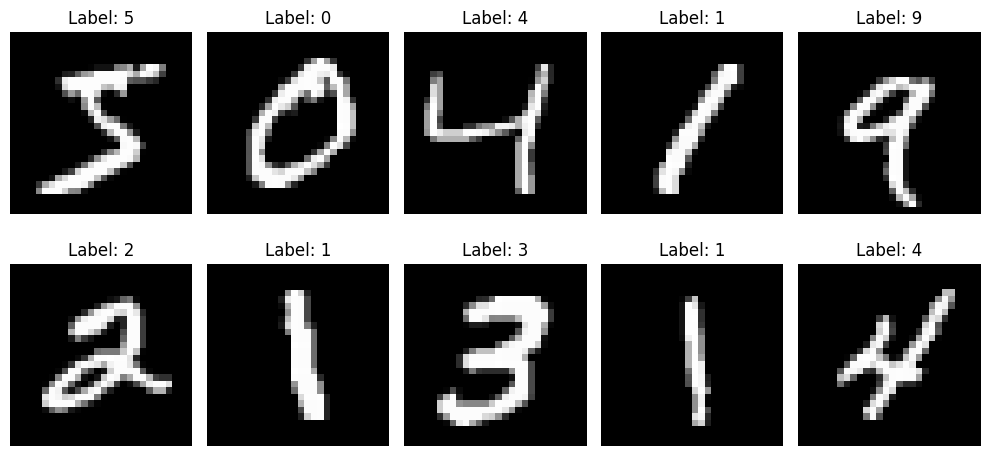

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print(x_train_flat.shape)
print(x_test_flat.shape)

(10000, 784)
(2000, 784)


In [ ]:
  encoder_input = keras.Input(shape=(784,))

x = layers.Dense(128, activation="relu")(encoder_input)
x = layers.Dense(32, activation="relu")(x)

latent = layers.Dense(16, activation="relu", name="latent")(x)

encoder = keras.Model(encoder_input, latent, name="encoder")

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,136 (410.69 KB)

 Trainable params: 105,136 (410.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
latent = layers.Dense(16, activation="relu", name="latent")(x)

In [ ]:
decoder_input = keras.Input(shape=(16,))

x = layers.Dense(32, activation="relu")(decoder_input)
x = layers.Dense(128, activation="relu")(x)

decoder_output = layers.Dense(784, activation="sigmoid")(x)

decoder = keras.Model(decoder_input, decoder_output, name="decoder")

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,904 (413.69 KB)

 Trainable params: 105,904 (413.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder_input = keras.Input(shape=(784,))

encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = keras.Model(
    autoencoder_input,
    decoded,
    name="fully_connected_autoencoder"
)

autoencoder.summary()

Model: "fully_connected_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 16)             │       105,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       105,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

autoencoder.compile(
    optimizer=optimizer,
    loss="binary_crossentropy"
)

In [ ]:
history_fc = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_flat, x_test_flat),
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.3483 - val_loss: 0.2449
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2305 - val_loss: 0.2084
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1984 - val_loss: 0.1869
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1803 - val_loss: 0.1752
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1697 - val_loss: 0.1676
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1624 - val_loss: 0.1618
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1570 - val_loss: 0.1556
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1522 - val_loss: 0.1522
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1481 - val_loss: 0.1484
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1447 - val_loss: 0.1456
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1420 - val_loss: 0.1434
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1396 - val_l

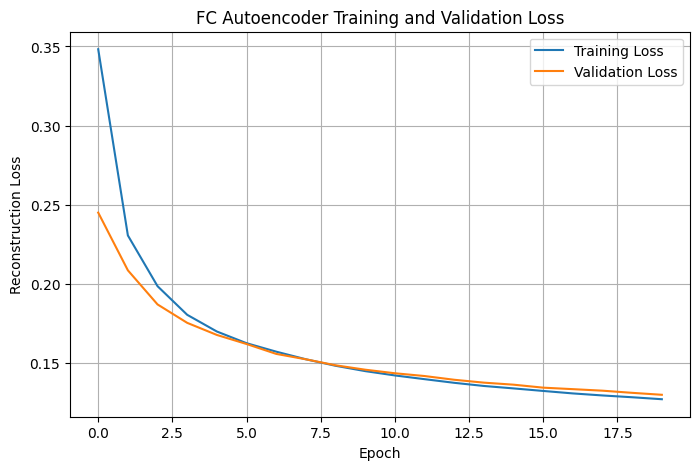

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_fc.history["loss"], label="Training Loss")
plt.plot(history_fc.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("FC Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
x_test_reconstructed_flat = autoencoder.predict(
    x_test_flat
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
print(x_test_reconstructed_flat.shape)

(2000, 784)


In [ ]:
x_test_reconstructed = x_test_reconstructed_flat.reshape(
    -1, 28, 28, 1
)

print(x_test_reconstructed.shape)

(2000, 28, 28, 1)


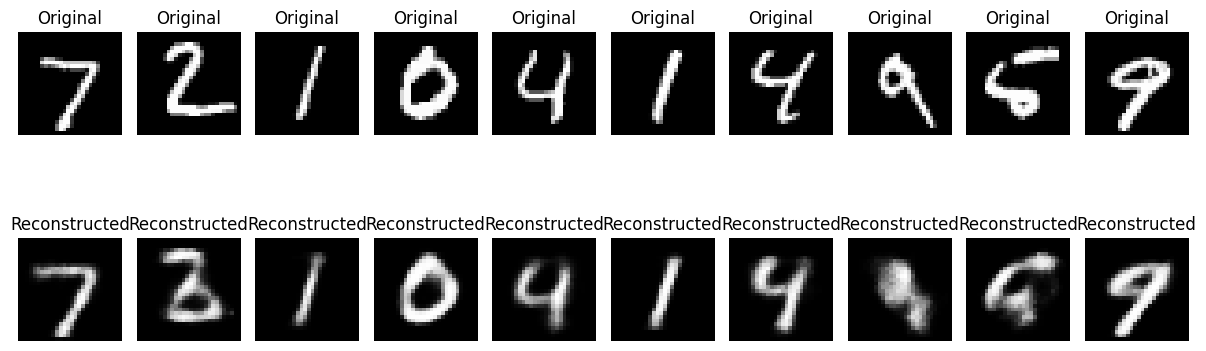

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(x_test_reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
mse = np.mean(
    (x_test - x_test_reconstructed) ** 2
)

print("Test MSE:", mse)

Test MSE: 0.02293511


In [ ]:
mae = np.mean(
    np.abs(x_test - x_test_reconstructed)
)

print("Test MAE:", mae)

Test MAE: 0.06027005


In [ ]:
ssim_values = []

for i in range(len(x_test)):

    original = x_test[i].squeeze()
    reconstructed = x_test_reconstructed[i].squeeze()

    score = ssim(
        original,
        reconstructed,
        data_range=1.0
    )

    ssim_values.append(score)

mean_ssim = np.mean(ssim_values)

print("Mean SSIM:", mean_ssim)

Mean SSIM: 0.7259224337992255


In [ ]:
print("===== FC AUTOENCODER =====")
print("Test MSE :", mse)
print("Test MAE :", mae)
print("Mean SSIM:", mean_ssim)

===== FC AUTOENCODER =====
Test MSE : 0.02293511
Test MAE : 0.06027005
Mean SSIM: 0.7259224337992255


In [ ]:
cae_input = keras.Input(shape=(28, 28, 1))

In [ ]:
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(cae_input)

In [ ]:
x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

In [ ]:
x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

In [ ]:
x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

In [ ]:
latent_cae = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

In [ ]:
x = layers.UpSampling2D((2, 2))(latent_cae)

In [ ]:
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

In [ ]:
x = layers.UpSampling2D((2, 2))(x)

In [ ]:
cae_output = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

In [ ]:
cae_input = keras.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(cae_input)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

latent_cae = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

# Decoder
x = layers.UpSampling2D((2, 2))(latent_cae)

x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

cae_output = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

cae = keras.Model(
    cae_input,
    cae_output,
    name="convolutional_autoencoder"
)

cae.summary()

Model: "convolutional_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

In [ ]:
history_cae = cae.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, x_test),
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 0.2089 - val_loss: 0.0992
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0912 - val_loss: 0.0848
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0824 - val_loss: 0.0783
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0781 - val_loss: 0.0753
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0759 - val_loss: 0.0734
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0742 - val_loss: 0.0721
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0730 - val_loss: 0.0713
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0722 - val_loss: 0.0704
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0715 - val_loss: 0.0697
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0710 - val_loss: 0.0694
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0704 - val_loss: 0.0689
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0702 - val_l

In [ ]:
input  = x_train
target = x_train

In [ ]:
x_test_cae_reconstructed = cae.predict(x_test)

print(x_test_cae_reconstructed.shape)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
(2000, 28, 28, 1)


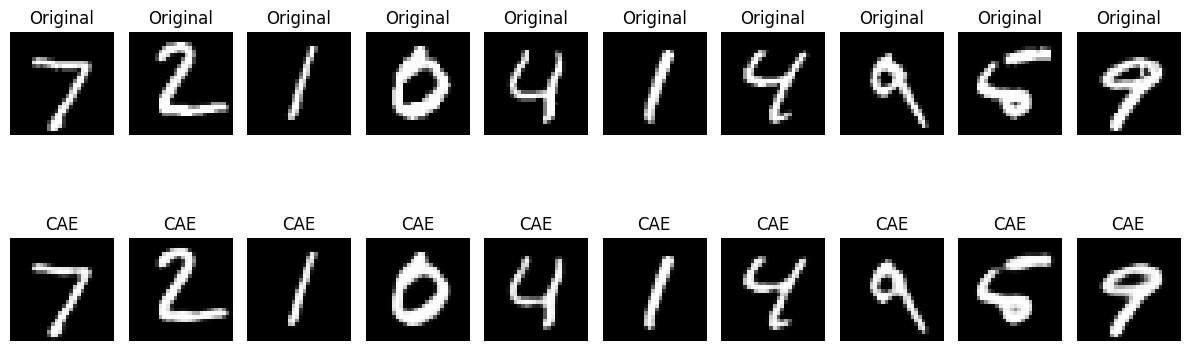

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # CAE reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(
        x_test_cae_reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.title("CAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# FC-AE reconstruction

fc_reconstructed = autoencoder.predict(x_test_flat)

fc_reconstructed = fc_reconstructed.reshape(
    -1, 28, 28, 1
)

# MSE
fc_mse = np.mean(
    (x_test - fc_reconstructed) ** 2
)

# MAE
fc_mae = np.mean(
    np.abs(x_test - fc_reconstructed)
)

# SSIM
fc_ssim_values = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i].squeeze(),
        fc_reconstructed[i].squeeze(),
        data_range=1.0
    )
    fc_ssim_values.append(score)

fc_ssim = np.mean(fc_ssim_values)

print("FC-AE MSE :", fc_mse)
print("FC-AE MAE :", fc_mae)
print("FC-AE SSIM:", fc_ssim)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
FC-AE MSE : 0.02293511
FC-AE MAE : 0.06027005
FC-AE SSIM: 0.7259224337992255


In [ ]:
# CAE reconstruction

cae_reconstructed = cae.predict(x_test)

# MSE
cae_mse = np.mean(
    (x_test - cae_reconstructed) ** 2
)

# MAE
cae_mae = np.mean(
    np.abs(x_test - cae_reconstructed)
)

# SSIM
cae_ssim_values = []

for i in range(len(x_test)):
    score = ssim(
        x_test[i].squeeze(),
        cae_reconstructed[i].squeeze(),
        data_range=1.0
    )
    cae_ssim_values.append(score)

cae_ssim = np.mean(cae_ssim_values)

print("CAE MSE :", cae_mse)
print("CAE MAE :", cae_mae)
print("CAE SSIM:", cae_ssim)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CAE MSE : 0.00243354
CAE MAE : 0.014603904
CAE SSIM: 0.9752219691266216


In [ ]:
print("FC-AE Parameters :", autoencoder.count_params())
print("CAE Parameters   :", cae.count_params())

FC-AE Parameters : 211040
CAE Parameters   : 74497


In [ ]:
print("\n===== MODEL COMPARISON =====")

print(f"{'Model':<20} {'MSE':<15} {'MAE':<15} {'SSIM':<15} {'Parameters'}")

print(
    f"{'FC Autoencoder':<20} "
    f"{fc_mse:<15.6f} "
    f"{fc_mae:<15.6f} "
    f"{fc_ssim:<15.6f} "
    f"{autoencoder.count_params()}"
)

print(
    f"{'Convolutional AE':<20} "
    f"{cae_mse:<15.6f} "
    f"{cae_mae:<15.6f} "
    f"{cae_ssim:<15.6f} "
    f"{cae.count_params()}"
)


===== MODEL COMPARISON =====
Model                MSE             MAE             SSIM            Parameters
FC Autoencoder       0.022935        0.060270        0.725922        211040
Convolutional AE     0.002434        0.014604        0.975222        74497


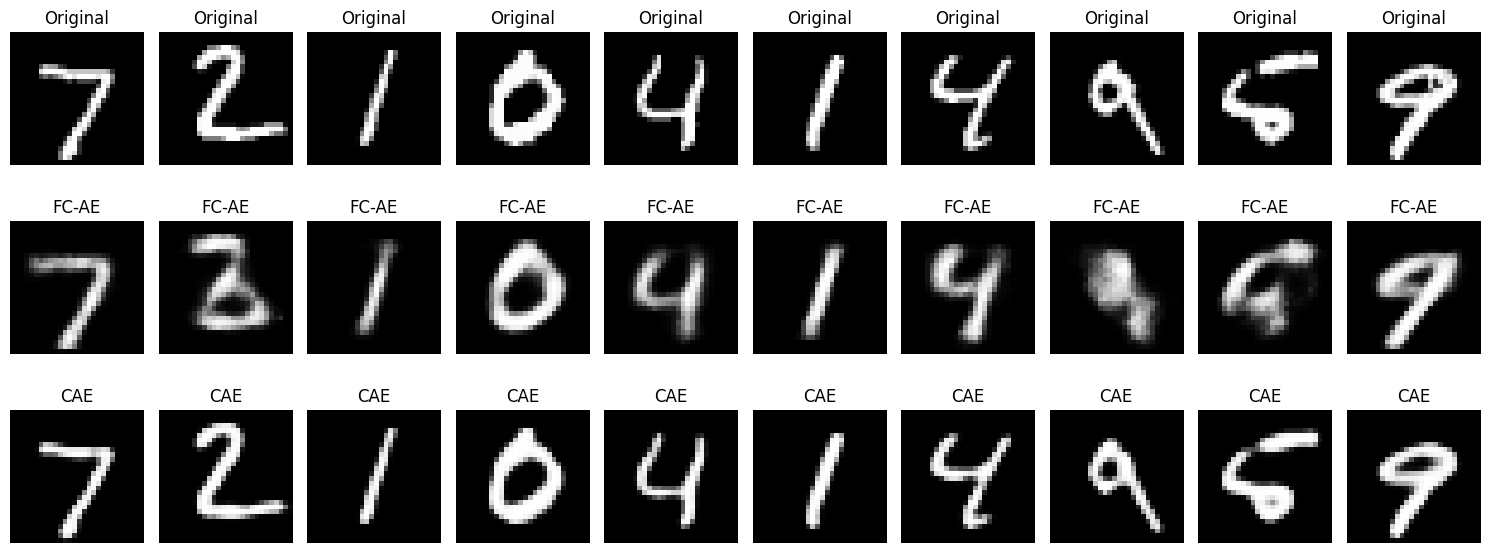

In [ ]:
plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # FC-AE
    plt.subplot(3, 10, i + 11)
    plt.imshow(
        fc_reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.title("FC-AE")
    plt.axis("off")

    # CAE
    plt.subplot(3, 10, i + 21)
    plt.imshow(
        cae_reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.title("CAE")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def add_gaussian_noise(images, sigma):

    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=images.shape
    )

    noisy_images = images + noise

    noisy_images = np.clip(
        noisy_images,
        0.0,
        1.0
    )

    return noisy_images

In [ ]:
x_test_gaussian_01 = add_gaussian_noise(
    x_test,
    0.1
)

x_test_gaussian_02 = add_gaussian_noise(
    x_test,
    0.2
)

x_test_gaussian_03 = add_gaussian_noise(
    x_test,
    0.3
)

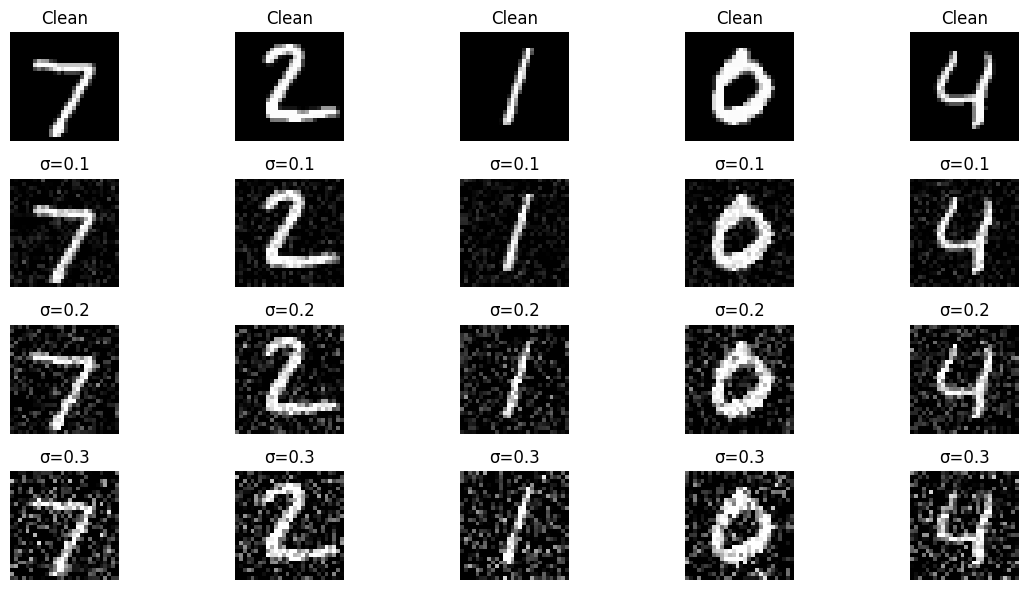

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(5):

    # Clean
    plt.subplot(4, 5, i + 1)
    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    plt.title("Clean")
    plt.axis("off")

    # σ = 0.1
    plt.subplot(4, 5, i + 6)
    plt.imshow(
        x_test_gaussian_01[i].squeeze(),
        cmap="gray"
    )
    plt.title("σ=0.1")
    plt.axis("off")

    # σ = 0.2
    plt.subplot(4, 5, i + 11)
    plt.imshow(
        x_test_gaussian_02[i].squeeze(),
        cmap="gray"
    )
    plt.title("σ=0.2")
    plt.axis("off")

    # σ = 0.3
    plt.subplot(4, 5, i + 16)
    plt.imshow(
        x_test_gaussian_03[i].squeeze(),
        cmap="gray"
    )
    plt.title("σ=0.3")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def add_salt_pepper_noise(images, probability):

    noisy_images = images.copy()

    random_values = np.random.random(
        images.shape
    )

    # Salt: pixel becomes 1
    salt_mask = random_values < probability / 2

    # Pepper: pixel becomes 0
    pepper_mask = (
        random_values >= probability / 2
    ) & (
        random_values < probability
    )

    noisy_images[salt_mask] = 1.0
    noisy_images[pepper_mask] = 0.0

    return noisy_images

In [ ]:
x_test_sp_005 = add_salt_pepper_noise(
    x_test,
    0.05
)

x_test_sp_010 = add_salt_pepper_noise(
    x_test,
    0.10
)

x_test_sp_020 = add_salt_pepper_noise(
    x_test,
    0.20
)

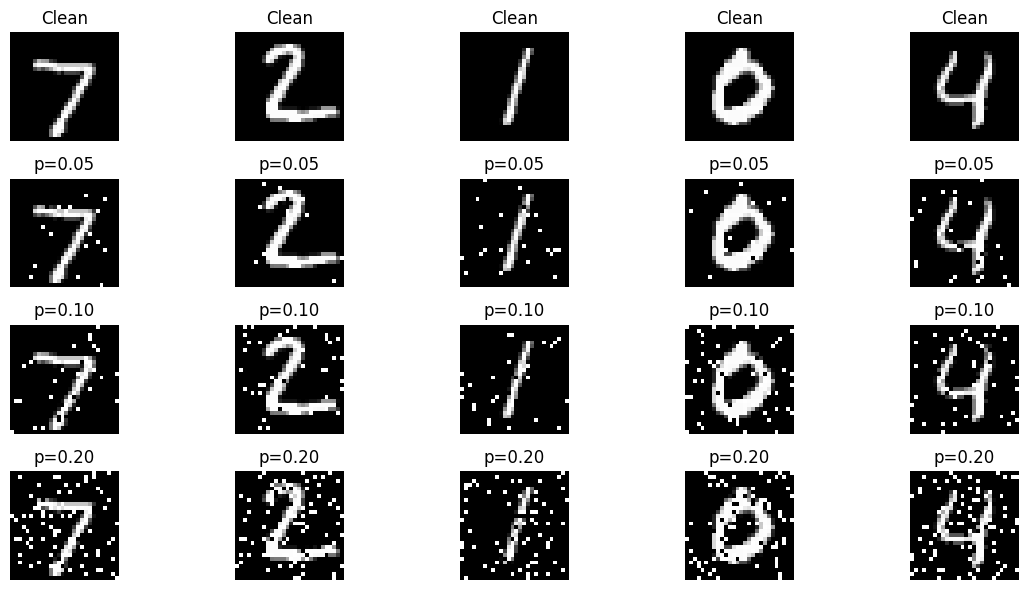

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(5):

    # Clean
    plt.subplot(4, 5, i + 1)
    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    plt.title("Clean")
    plt.axis("off")

    # p = 0.05
    plt.subplot(4, 5, i + 6)
    plt.imshow(
        x_test_sp_005[i].squeeze(),
        cmap="gray"
    )
    plt.title("p=0.05")
    plt.axis("off")

    # p = 0.10
    plt.subplot(4, 5, i + 11)
    plt.imshow(
        x_test_sp_010[i].squeeze(),
        cmap="gray"
    )
    plt.title("p=0.10")
    plt.axis("off")

    # p = 0.20
    plt.subplot(4, 5, i + 16)
    plt.imshow(
        x_test_sp_020[i].squeeze(),
        cmap="gray"
    )
    plt.title("p=0.20")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
denoise_input = keras.Input(
    shape=(28, 28, 1)
)

# Encoder
x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(denoise_input)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.MaxPooling2D(
    (2, 2),
    padding="same"
)(x)

x = layers.Conv2D(
    64,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

# Decoder
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(
    32,
    (3, 3),
    activation="relu",
    padding="same"
)(x)

x = layers.UpSampling2D((2, 2))(x)

denoise_output = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

denoising_cae = keras.Model(
    denoise_input,
    denoise_output,
    name="denoising_cae"
)

In [ ]:
denoising_cae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy"
)

In [ ]:
x_train_noisy = add_gaussian_noise(
    x_train,
    sigma=0.2
)

In [ ]:
denoising_cae.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_gaussian_02, x_test),
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.2747 - val_loss: 0.1229
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1072 - val_loss: 0.0949
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0923 - val_loss: 0.0874
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0870 - val_loss: 0.0843
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0842 - val_loss: 0.0818
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0821 - val_loss: 0.0803
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0808 - val_loss: 0.0797
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0799 - val_loss: 0.0779
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0790 - val_loss: 0.0780
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0783 - val_loss: 0.0766
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0778 - val_loss: 0.0761
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0774 - val_l

In [ ]:
denoised_test = denoising_cae.predict(
    x_test_gaussian_02
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


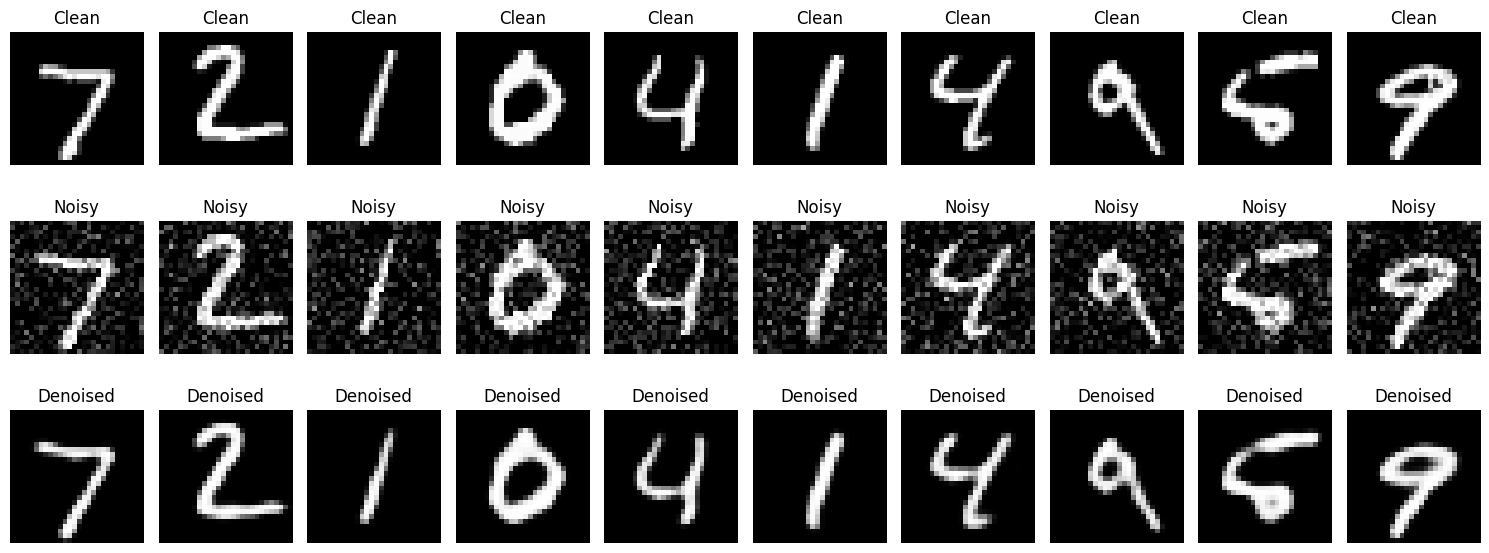

In [ ]:
plt.figure(figsize=(15, 6))

for i in range(10):

    # Clean
    plt.subplot(3, 10, i + 1)
    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    plt.title("Clean")
    plt.axis("off")

    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(
        x_test_gaussian_02[i].squeeze(),
        cmap="gray"
    )
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(
        denoised_test[i].squeeze(),
        cmap="gray"
    )
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
denoise_mse = np.mean(
    (x_test - denoised_test) ** 2
)

denoise_mae = np.mean(
    np.abs(x_test - denoised_test)
)

denoise_ssim_values = []

for i in range(len(x_test)):

    score = ssim(
        x_test[i].squeeze(),
        denoised_test[i].squeeze(),
        data_range=1.0
    )

    denoise_ssim_values.append(score)

denoise_ssim = np.mean(
    denoise_ssim_values
)

print("Denoising MSE :", denoise_mse)
print("Denoising MAE :", denoise_mae)
print("Denoising SSIM:", denoise_ssim)

Denoising MSE : 0.004438489
Denoising MAE : 0.020654157
Denoising SSIM: 0.9468041988849987


In [ ]:
noisy_test_01 = add_gaussian_noise(
    x_test,
    0.1
)

noisy_test_02 = add_gaussian_noise(
    x_test,
    0.2
)

noisy_test_03 = add_gaussian_noise(
    x_test,
    0.3
)

In [ ]:
denoised_01 = denoising_cae.predict(
    noisy_test_01
)

denoised_02 = denoising_cae.predict(
    noisy_test_02
)

denoised_03 = denoising_cae.predict(
    noisy_test_03
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
def calculate_metrics(original, reconstructed):

    mse = np.mean(
        (original - reconstructed) ** 2
    )

    mae = np.mean(
        np.abs(original - reconstructed)
    )

    ssim_scores = []

    for i in range(len(original)):

        score = ssim(
            original[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )

        ssim_scores.append(score)

    mean_ssim = np.mean(ssim_scores)

    return mse, mae, mean_ssim

In [ ]:
mse_01, mae_01, ssim_01 = calculate_metrics(
    x_test,
    denoised_01
)

mse_02, mae_02, ssim_02 = calculate_metrics(
    x_test,
    denoised_02
)

mse_03, mae_03, ssim_03 = calculate_metrics(
    x_test,
    denoised_03
)

In [ ]:
print("\nNoise Level | MSE       | MAE       | SSIM")
print("---------------------------------------------")

print(
    f"0.1         | {mse_01:.6f} | "
    f"{mae_01:.6f} | {ssim_01:.6f}"
)

print(
    f"0.2         | {mse_02:.6f} | "
    f"{mae_02:.6f} | {ssim_02:.6f}"
)

print(
    f"0.3         | {mse_03:.6f} | "
    f"{mae_03:.6f} | {ssim_03:.6f}"
)


Noise Level | MSE       | MAE       | SSIM
---------------------------------------------
0.1         | 0.003457 | 0.017262 | 0.960780
0.2         | 0.004443 | 0.020686 | 0.946638
0.3         | 0.006832 | 0.028409 | 0.882987


In [ ]:
latent_dim = 2

vae_input = keras.Input(
    shape=(28, 28, 1)
)

x = layers.Conv2D(
    32,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(vae_input)

x = layers.Conv2D(
    64,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(128, activation="relu")(x)

In [ ]:
z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

In [ ]:
def sampling(args):

    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=tf.shape(z_mean)
    )

    sigma = tf.exp(
        0.5 * z_log_var
    )

    return z_mean + sigma * epsilon

In [ ]:
z = layers.Lambda(
    sampling,
    name="z"
)([z_mean, z_log_var])

In [ ]:
encoder_vae = keras.Model(
    vae_input,
    [z_mean, z_log_var, z],
    name="vae_encoder"
)

encoder_vae.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │    401,536 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder_input = keras.Input(
    shape=(latent_dim,)
)

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(decoder_input)

x = layers.Reshape(
    (7, 7, 64)
)(x)

x = layers.Conv2DTranspose(
    64,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    activation="relu",
    strides=2,
    padding="same"
)(x)

decoder_output = layers.Conv2D(
    1,
    3,
    activation="sigmoid",
    padding="same"
)(x)

decoder_vae = keras.Model(
    decoder_input,
    decoder_output,
    name="vae_decoder"
)

decoder_vae.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(keras.Model):

    def __init__(
        self,
        encoder,
        decoder,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                data,
                training=True
            )

            reconstruction = self.decoder(
                z,
                training=True
            )

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(
            data,
            training=False
        )

        reconstruction = self.decoder(
            z,
            training=False
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + kl_loss
        )

        return {
            "loss": total_loss,
            "reconstruction_loss":
                reconstruction_loss,
            "kl_loss":
                kl_loss
        }

In [ ]:
vae = VAE(
    encoder_vae,
    decoder_vae
)

In [ ]:
vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    )
)

In [ ]:
history_vae = vae.fit(
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, None)
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - kl_loss: 3.6763 - loss: 289.6144 - reconstruction_loss: 285.9380 - val_kl_loss: 3.7397 - val_loss: 195.9386 - val_reconstruction_loss: 192.1989
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - kl_loss: 3.2070 - loss: 200.8698 - reconstruction_loss: 197.6627 - val_kl_loss: 3.0709 - val_loss: 186.1092 - val_reconstruction_loss: 183.0383
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.0646 - loss: 192.3408 - reconstruction_loss: 189.2762 - val_kl_loss: 3.7963 - val_loss: 179.0737 - val_reconstruction_loss: 175.2774
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.9957 - loss: 182.1519 - reconstruction_loss: 178.1562 - val_kl_loss: 3.9678 - val_loss: 175.3368 - val_reconstruction_loss: 171.3690
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.2126 - loss: 178.1093 - reconstruction_loss: 173.8967 - val_kl_loss: 4.0407 - val_loss: 172.4408 - val_reconstruction_loss: 168.4001
Epoch 6/20
79/79

In [ ]:
z_mean_test, z_log_var_test, z_test = encoder_vae.predict(
    x_test
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


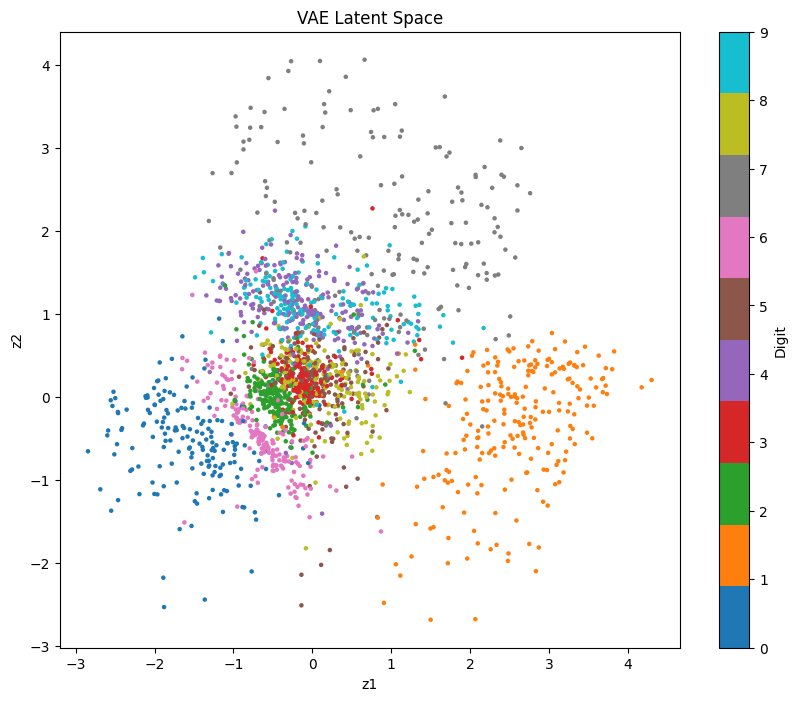

In [ ]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE Latent Space")

plt.colorbar(
    scatter,
    label="Digit"
)

plt.show()

In [ ]:
random_latent_vectors = np.random.normal(
    size=(25, latent_dim)
)

In [ ]:
generated_images = decoder_vae.predict(
    random_latent_vectors
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step


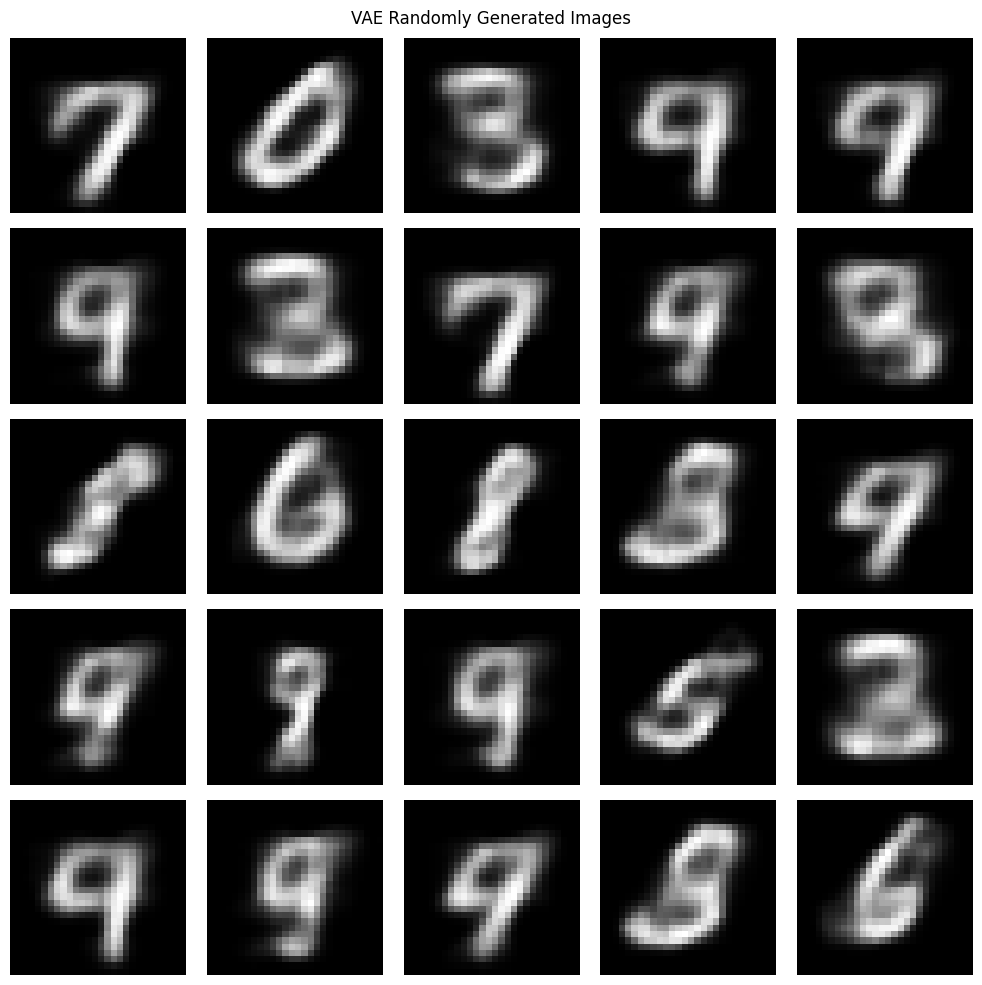

In [ ]:
plt.figure(figsize=(10, 10))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "VAE Randomly Generated Images"
)

plt.tight_layout()
plt.show()

In [ ]:
zA = z_mean_test[0]
zB = z_mean_test[1]

print("zA:", zA)
print("zB:", zB)

zA: [1.5647831 3.0077205]
zB: [-0.61330223  0.05429398]


In [ ]:
alphas = np.linspace(
    0,
    1,
    11
)

print(alphas)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [ ]:
interpolated_latents = []

for alpha in alphas:

    z = (
        (1 - alpha) * zA
        + alpha * zB
    )

    interpolated_latents.append(z)

interpolated_latents = np.array(
    interpolated_latents
)

print(
    interpolated_latents.shape
)

(11, 2)


In [ ]:
interpolated_images = decoder_vae.predict(
    interpolated_latents
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step


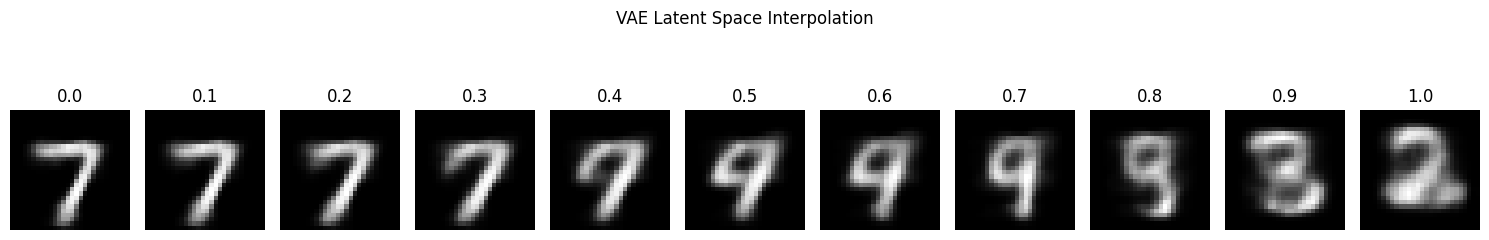

In [ ]:
plt.figure(figsize=(15, 3))

for i in range(11):

    plt.subplot(1, 11, i + 1)

    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"{alphas[i]:.1f}"
    )

    plt.axis("off")

plt.suptitle(
    "VAE Latent Space Interpolation"
)

plt.tight_layout()
plt.show()

In [ ]:
z_mean_test, z_log_var_test, z_test = encoder_vae.predict(
    x_test
)

vae_reconstructed = decoder_vae.predict(
    z_test
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
vae_mse = np.mean(
    (x_test - vae_reconstructed) ** 2
)

print("VAE Test MSE:", vae_mse)

VAE Test MSE: 0.044035178


In [ ]:
vae_mae = np.mean(
    np.abs(x_test - vae_reconstructed)
)

print("VAE Test MAE:", vae_mae)

VAE Test MAE: 0.10320554


In [ ]:
vae_ssim_values = []

for i in range(len(x_test)):

    score = ssim(
        x_test[i].squeeze(),
        vae_reconstructed[i].squeeze(),
        data_range=1.0
    )

    vae_ssim_values.append(score)

vae_ssim = np.mean(
    vae_ssim_values
)

print("VAE Mean SSIM:", vae_ssim)

VAE Mean SSIM: 0.4747132942889988


In [ ]:
vae_results = vae.evaluate(
    x_test,
    return_dict=True
)

print(vae_results)

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - kl_loss: 5.5199 - loss: 142.8899 - reconstruction_loss: 137.3700
{'loss': <tf.Tensor: shape=(), dtype=float32, numpy=142.88986206054688>, 'reconstruction_loss': <tf.Tensor: shape=(), dtype=float32, numpy=137.37001037597656>, 'kl_loss': <tf.Tensor: shape=(), dtype=float32, numpy=5.519859313964844>}


In [ ]:
vae_total_loss = vae_results["loss"]

vae_reconstruction_loss = (
    vae_results["reconstruction_loss"]
)

vae_kl_loss = (
    vae_results["kl_loss"]
)

In [ ]:
print("\n========== RECONSTRUCTION COMPARISON ==========")

print(
    f"{'Model':<25}"
    f"{'MSE':<15}"
    f"{'MAE':<15}"
    f"{'SSIM':<15}"
    f"{'Parameters'}"
)

print(
    f"{'FC Autoencoder':<25}"
    f"{fc_mse:<15.6f}"
    f"{fc_mae:<15.6f}"
    f"{fc_ssim:<15.6f}"
    f"{autoencoder.count_params()}"
)

print(
    f"{'Convolutional AE':<25}"
    f"{cae_mse:<15.6f}"
    f"{cae_mae:<15.6f}"
    f"{cae_ssim:<15.6f}"
    f"{cae.count_params()}"
)

print(
    f"{'Denoising CAE':<25}"
    f"{denoise_mse:<15.6f}"
    f"{denoise_mae:<15.6f}"
    f"{denoise_ssim:<15.6f}"
    f"{denoising_cae.count_params()}"
)


========== RECONSTRUCTION COMPARISON ==========
Model                    MSE            MAE            SSIM           Parameters
FC Autoencoder           0.022935       0.060270       0.725922       211040
Convolutional AE         0.002434       0.014604       0.975222       74497
Denoising CAE            0.004438       0.020654       0.946804       74497


In [ ]:
vae.build((None, 28, 28, 1))

In [ ]:
print("\n========== VAE RESULTS ==========")

print(
    "Reconstruction Loss:",
    vae_reconstruction_loss
)

print(
    "KL Loss:",
    vae_kl_loss
)

print(
    "Total Loss:",
    vae_total_loss
)

print(
    "Test MSE:",
    vae_mse
)

print(
    "Test MAE:",
    vae_mae
)

print(
    "Mean SSIM:",
    vae_ssim
)

print(
    "Parameters:",
    vae.count_params()
)


========== VAE RESULTS ==========
Reconstruction Loss: tf.Tensor(137.37001, shape=(), dtype=float32)
KL Loss: tf.Tensor(5.5198593, shape=(), dtype=float32)
Total Loss: tf.Tensor(142.88986, shape=(), dtype=float32)
Test MSE: 0.044035178
Test MAE: 0.10320554
Mean SSIM: 0.4747132942889988
Parameters: 485957


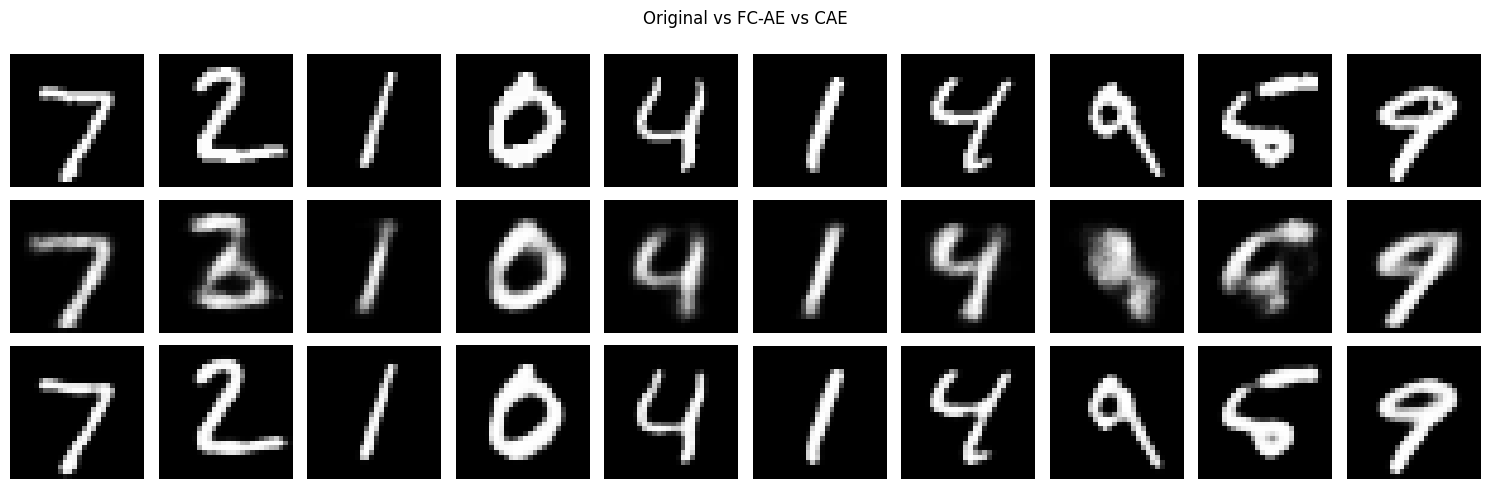

In [ ]:
# Select 10 test images
num_images = 10

plt.figure(figsize=(15, 5))

for i in range(num_images):
    # Original
    plt.subplot(3, num_images, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    # FC-AE
    plt.subplot(3, num_images, num_images + i + 1)
    plt.imshow(x_test_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("FC-AE")

    # CAE
    plt.subplot(3, num_images, 2 * num_images + i + 1)
    plt.imshow(cae_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("CAE")

plt.suptitle("Original vs FC-AE vs CAE")
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


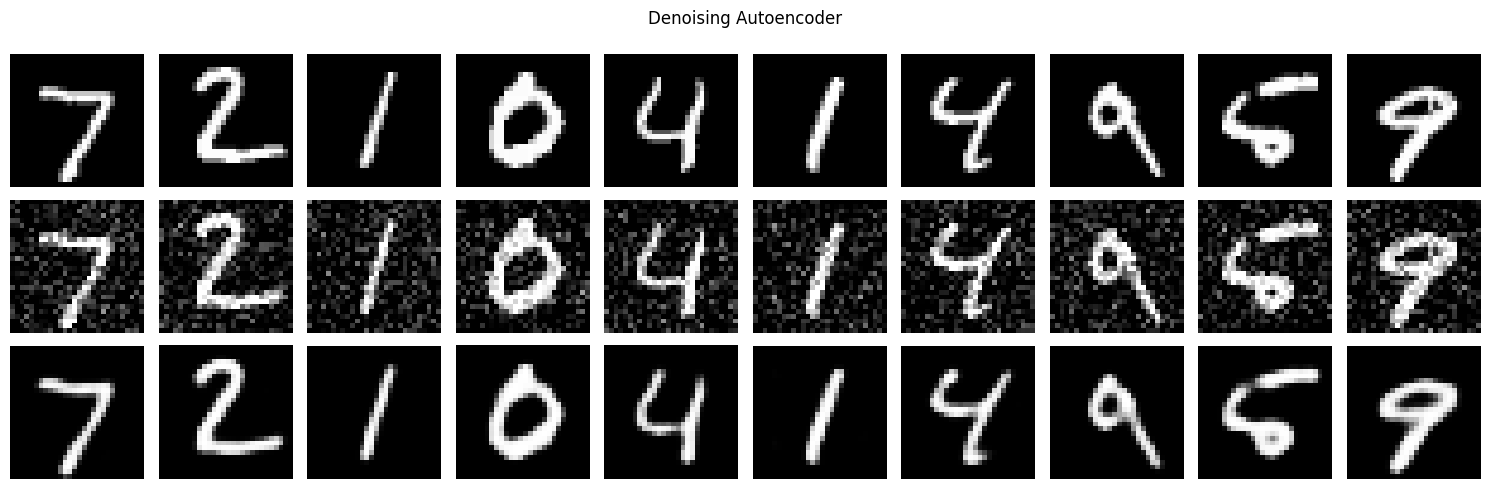

In [ ]:
# Generate noisy test images using Gaussian noise sigma = 0.2
x_test_noisy = add_gaussian_noise(x_test, 0.2)

# Denoise
x_test_denoised = denoising_cae.predict(x_test_noisy)

plt.figure(figsize=(15, 5))

for i in range(num_images):

    # Clean
    plt.subplot(3, num_images, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Clean")

    # Noisy
    plt.subplot(3, num_images, num_images + i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Noisy")

    # Denoised
    plt.subplot(3, num_images, 2 * num_images + i + 1)
    plt.imshow(x_test_denoised[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Denoised")

plt.suptitle("Denoising Autoencoder")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


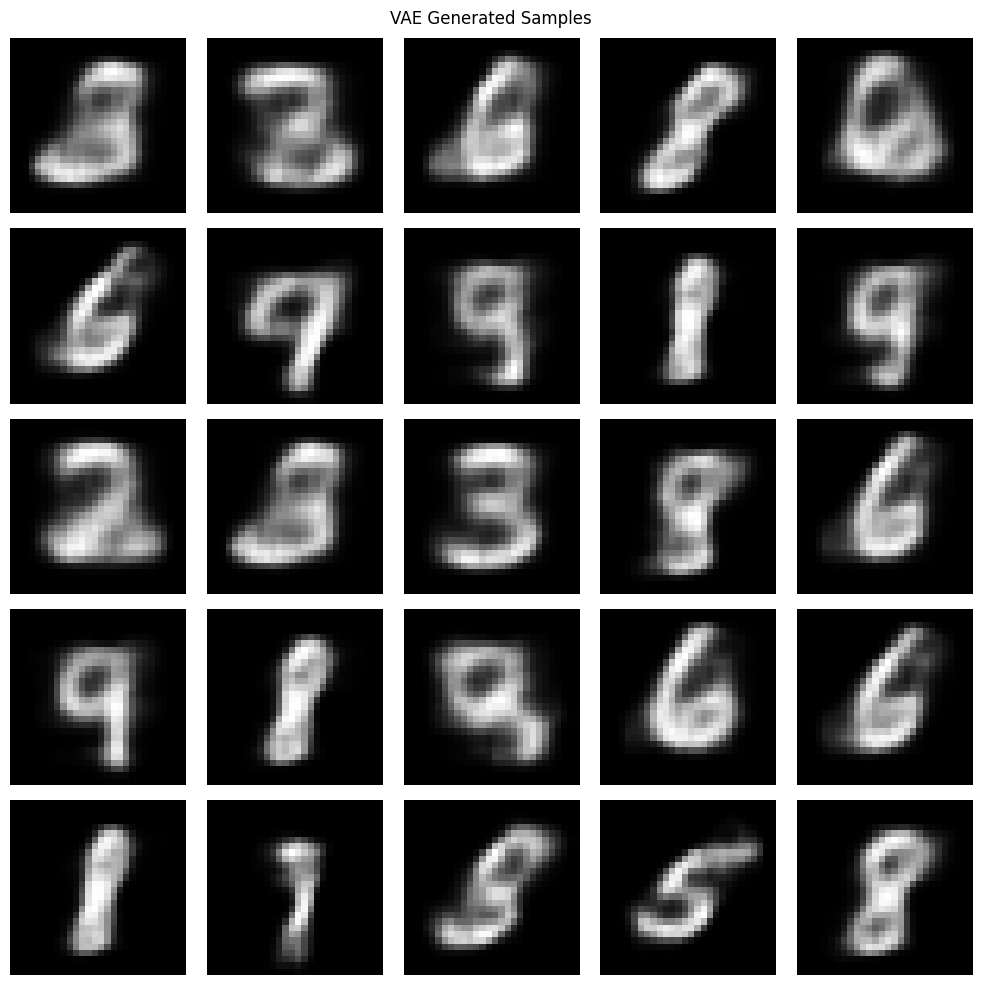

In [ ]:
# Generate 25 random latent vectors
random_latent_vectors = np.random.normal(
    size=(25, latent_dim)
)

generated_images = decoder_vae.predict(random_latent_vectors)

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("VAE Generated Samples")
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


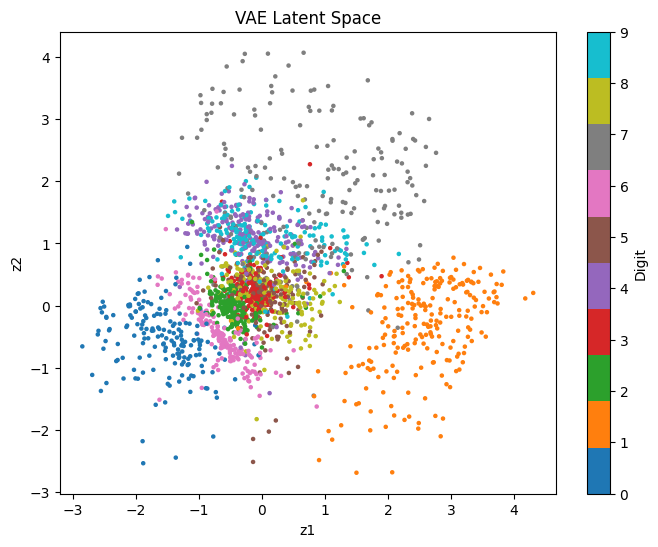

In [ ]:
# Get latent means
z_mean_test, z_log_var_test, z_test = encoder_vae.predict(x_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE Latent Space")

plt.colorbar(label="Digit")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


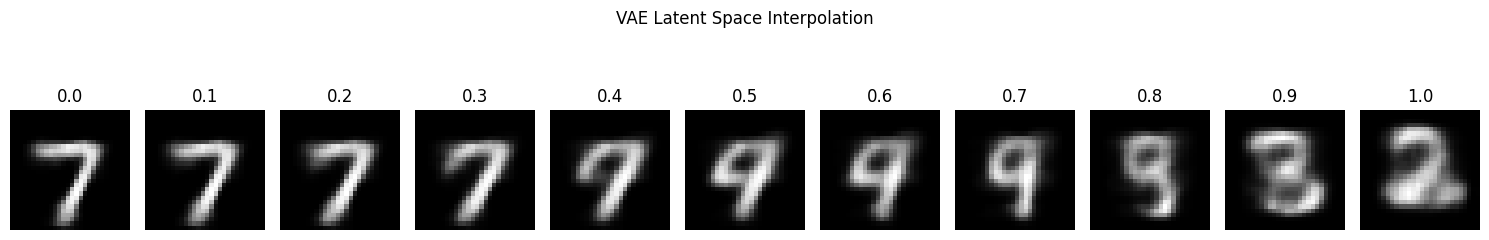

In [ ]:
# Select two latent points
zA = z_mean_test[0]
zB = z_mean_test[1]

# Alpha = 0, 0.1, ..., 1
alphas = np.linspace(0, 1, 11)

interpolated_latents = np.array([
    (1 - alpha) * zA + alpha * zB
    for alpha in alphas
])

# Decode
interpolated_images = decoder_vae.predict(
    interpolated_latents
)

plt.figure(figsize=(15, 3))

for i in range(11):
    plt.subplot(1, 11, i + 1)
    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )
    plt.axis("off")
    plt.title(f"{alphas[i]:.1f}")

plt.suptitle("VAE Latent Space Interpolation")
plt.tight_layout()
plt.show()

In [ ]:
# FC-AE reconstruction error for every image
fc_mse_per_image = np.mean(
    (x_test - x_test_reconstructed) ** 2,
    axis=(1, 2, 3)
)

# CAE reconstruction error for every image
cae_mse_per_image = np.mean(
    (x_test - cae_reconstructed) ** 2,
    axis=(1, 2, 3)
)

# Denoising CAE reconstruction error
denoising_mse_per_image = np.mean(
    (x_test - x_test_denoised) ** 2,
    axis=(1, 2, 3)
)

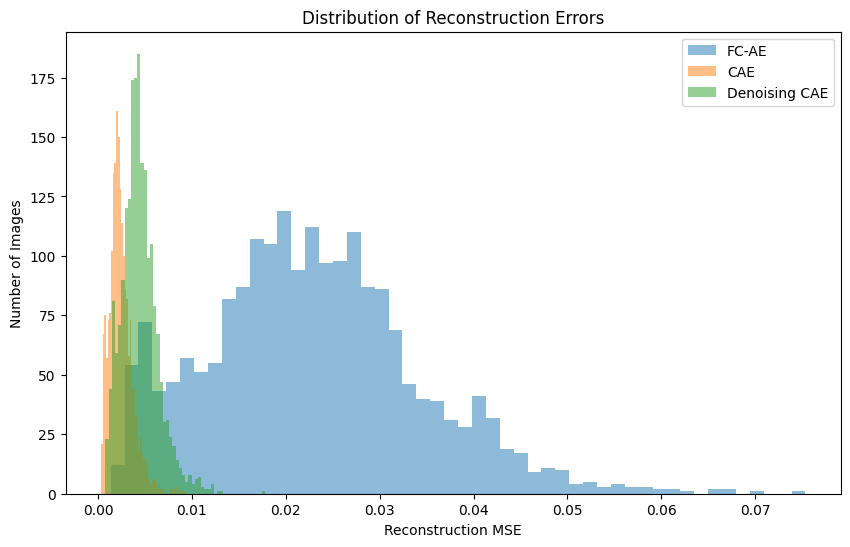

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    fc_mse_per_image,
    bins=50,
    alpha=0.5,
    label="FC-AE"
)

plt.hist(
    cae_mse_per_image,
    bins=50,
    alpha=0.5,
    label="CAE"
)

plt.hist(
    denoising_mse_per_image,
    bins=50,
    alpha=0.5,
    label="Denoising CAE"
)

plt.xlabel("Reconstruction MSE")
plt.ylabel("Number of Images")
plt.title("Distribution of Reconstruction Errors")
plt.legend()

plt.show()

In [ ]:
# Find indices of top 5 highest-error images
top_5_indices = np.argsort(fc_mse_per_image)[-5:]

# Sort from highest error to lowest error
top_5_indices = top_5_indices[::-1]

print("Top 5 high-error image indices:")
print(top_5_indices)

print("\nTheir reconstruction MSE:")
for index in top_5_indices:
    print(
        "Image:", index,
        "MSE:", fc_mse_per_image[index],
        "Digit:", y_test[index]
    )

Top 5 high-error image indices:
[1782  338  654 1790 1170]

Their reconstruction MSE:
Image: 1782 MSE: 0.07536048 Digit: 8
Image: 338 MSE: 0.06963574 Digit: 8
Image: 654 MSE: 0.06769455 Digit: 5
Image: 1790 MSE: 0.067245156 Digit: 2
Image: 1170 MSE: 0.06577681 Digit: 8


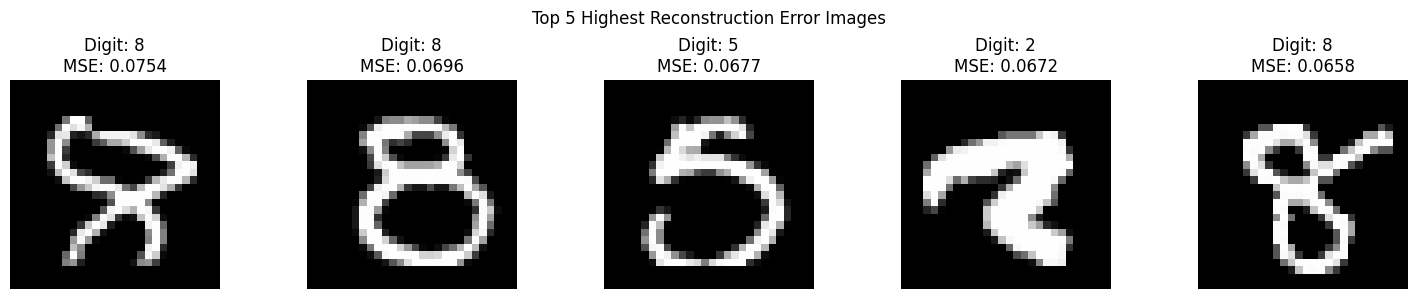

In [ ]:
plt.figure(figsize=(15, 3))

for i, index in enumerate(top_5_indices):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        x_test[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Digit: {y_test[index]}\n"
        f"MSE: {fc_mse_per_image[index]:.4f}"
    )

    plt.axis("off")

plt.suptitle("Top 5 Highest Reconstruction Error Images")
plt.tight_layout()
plt.show()

In [ ]:
# Denoising CAE metrics
denoising_mse, denoising_mae, denoising_ssim = calculate_metrics(
    x_test,
    x_test_denoised
)

print("Denoising CAE")
print("MSE :", denoising_mse)
print("MAE :", denoising_mae)
print("SSIM:", denoising_ssim)

Denoising CAE
MSE : 0.004442971
MAE : 0.02068869
SSIM: 0.9467290662657772


In [ ]:
fc_parameters = autoencoder.count_params()

cae_parameters = cae.count_params()

denoising_parameters = denoising_cae.count_params()

vae_parameters = (
    encoder_vae.count_params()
    + decoder_vae.count_params()
)

print("FC-AE Parameters:", fc_parameters)
print("CAE Parameters:", cae_parameters)
print("Denoising CAE Parameters:", denoising_parameters)
print("VAE Parameters:", vae_parameters)

FC-AE Parameters: 211040
CAE Parameters: 74497
Denoising CAE Parameters: 74497
VAE Parameters: 485957


In [ ]:
# Denoising CAE metrics
denoising_mse, denoising_mae, denoising_ssim = calculate_metrics(
    x_test,
    x_test_denoised
)

print("Denoising CAE")
print("MSE :", denoising_mse)
print("MAE :", denoising_mae)
print("SSIM:", denoising_ssim)

Denoising CAE
MSE : 0.004442971
MAE : 0.02068869
SSIM: 0.9467290662657772


In [ ]:
fc_parameters = autoencoder.count_params()

cae_parameters = cae.count_params()

denoising_parameters = denoising_cae.count_params()

vae_parameters = (
    encoder_vae.count_params()
    + decoder_vae.count_params()
)

print("FC-AE Parameters:", fc_parameters)
print("CAE Parameters:", cae_parameters)
print("Denoising CAE Parameters:", denoising_parameters)
print("VAE Parameters:", vae_parameters)

FC-AE Parameters: 211040
CAE Parameters: 74497
Denoising CAE Parameters: 74497
VAE Parameters: 485957


In [ ]:
print("\n========== CONSOLIDATED RESULTS ==========")

print("\nFC-AE")
print("MSE       :", mse)
print("MAE       :", mae)
print("SSIM      :", mean_ssim)
print("Parameters:", fc_parameters)

print("\nCAE")
print("MSE       :", cae_mse)
print("MAE       :", cae_mae)
print("SSIM      :", cae_ssim)
print("Parameters:", cae_parameters)

print("\nDenoising CAE")
print("MSE       :", denoising_mse)
print("MAE       :", denoising_mae)
print("SSIM      :", denoising_ssim)
print("Parameters:", denoising_parameters)

print("\nVAE")
print("Reconstruction Loss:", vae_reconstruction_loss)
print("KL Loss            :", vae_kl_loss)
print("Total Loss         :", vae_total_loss)
print("Test MSE           :", vae_mse)
print("Test MAE           :", vae_mae)
print("Mean SSIM          :", vae_ssim)
print("Parameters         :", vae_parameters)


========== CONSOLIDATED RESULTS ==========

FC-AE
MSE       : 0.02293511
MAE       : 0.06027005
SSIM      : 0.7259224337992255
Parameters: 211040

CAE
MSE       : 0.00243354
MAE       : 0.014603904
SSIM      : 0.9752219691266216
Parameters: 74497

Denoising CAE
MSE       : 0.004442971
MAE       : 0.02068869
SSIM      : 0.9467290662657772
Parameters: 74497

VAE
Reconstruction Loss: tf.Tensor(137.37001, shape=(), dtype=float32)
KL Loss            : tf.Tensor(5.5198593, shape=(), dtype=float32)
Total Loss         : tf.Tensor(142.88986, shape=(), dtype=float32)
Test MSE           : 0.044035178
Test MAE           : 0.10320554
Mean SSIM          : 0.4747132942889988
Parameters         : 485957


In [ ]:
import pandas as pd

results_table = pd.DataFrame({
    "Model": [
        "FC-AE",
        "CAE",
        "Denoising CAE",
        "VAE"
    ],

    "MSE": [
        mse,
        cae_mse,
        denoising_mse,
        vae_mse
    ],

    "MAE": [
        mae,
        cae_mae,
        denoising_mae,
        vae_mae
    ],

    "SSIM": [
        mean_ssim,
        cae_ssim,
        denoising_ssim,
        vae_ssim
    ],

    "Parameters": [
        fc_parameters,
        cae_parameters,
        denoising_parameters,
        vae_parameters
    ]
})

results_table

,Model,MSE,MAE,SSIM,Parameters
0,FC-AE,0.022935,0.060270,0.725922,211040
1,CAE,0.002434,0.014604,0.975222,74497
2,Denoising CAE,0.004443,0.020689,0.946729,74497
3,VAE,0.044035,0.103206,0.474713,485957


In [ ]:
vae_loss_table = pd.DataFrame({
    "Metric": [
        "Reconstruction Loss",
        "KL Loss",
        "Total Loss"
    ],

    "Value": [
        float(vae_reconstruction_loss),
        float(vae_kl_loss),
        float(vae_total_loss)
    ]
})

vae_loss_table

,Metric,Value
0,Reconstruction Loss,137.370010
1,KL Loss,5.519859
2,Total Loss,142.889862


In [ ]:
def build_fc_autoencoder(latent_dim):

    # Encoder
    encoder_input = keras.Input(shape=(784,))

    x = layers.Dense(
        128,
        activation="relu"
    )(encoder_input)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    latent = layers.Dense(
        latent_dim,
        activation="relu"
    )(x)

    encoder = keras.Model(
        encoder_input,
        latent
    )

    # Decoder
    decoder_input = keras.Input(
        shape=(latent_dim,)
    )

    x = layers.Dense(
        32,
        activation="relu"
    )(decoder_input)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    decoder_output = layers.Dense(
        784,
        activation="sigmoid"
    )(x)

    decoder = keras.Model(
        decoder_input,
        decoder_output
    )

    # Complete autoencoder
    autoencoder_input = keras.Input(
        shape=(784,)
    )

    encoded = encoder(autoencoder_input)

    decoded = decoder(encoded)

    autoencoder = keras.Model(
        autoencoder_input,
        decoded
    )

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy"
    )

    return autoencoder

In [ ]:
latent_dimensions = [2, 8, 16, 32]

latent_models = {}
latent_results = {}

for latent_dim in latent_dimensions:

    print("\n================================")
    print("Training latent dimension:", latent_dim)
    print("================================")

    model = build_fc_autoencoder(latent_dim)

    history = model.fit(
        x_train_flat,
        x_train_flat,
        epochs=20,
        batch_size=128,
        validation_data=(
            x_test_flat,
            x_test_flat
        ),
        shuffle=True,
        verbose=1
    )

    latent_models[latent_dim] = model

    # Reconstruction
    reconstructed_flat = model.predict(
        x_test_flat
    )

    reconstructed = reconstructed_flat.reshape(
        -1, 28, 28, 1
    )

    # Metrics
    latent_mse = np.mean(
        (x_test - reconstructed) ** 2
    )

    latent_mae = np.mean(
        np.abs(x_test - reconstructed)
    )

    latent_ssim_values = [
        ssim(
            x_test[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_test))
    ]

    latent_ssim = np.mean(
        latent_ssim_values
    )

    parameters = model.count_params()

    latent_results[latent_dim] = {
        "MSE": latent_mse,
        "MAE": latent_mae,
        "SSIM": latent_ssim,
        "Parameters": parameters,
        "Reconstructed": reconstructed
    }

    print("MSE       :", latent_mse)
    print("MAE       :", latent_mae)
    print("SSIM      :", latent_ssim)
    print("Parameters:", parameters)


Training latent dimension: 2
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.3406 - val_loss: 0.2601
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2599 - val_loss: 0.2451
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2447 - val_loss: 0.2341
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2369 - val_loss: 0.2292
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2312 - val_loss: 0.2226
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2265 - val_loss: 0.2190
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2229 - val_loss: 0.2161
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2193 - val_loss: 0.2131
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2161 - val_loss: 0.2110
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2139 - val_loss: 0.2091
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2123 - val_loss: 0.2083
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [ ]:
latent_dimension_table = pd.DataFrame({
    "Latent Dimension": latent_dimensions,

    "MSE": [
        latent_results[d]["MSE"]
        for d in latent_dimensions
    ],

    "MAE": [
        latent_results[d]["MAE"]
        for d in latent_dimensions
    ],

    "SSIM": [
        latent_results[d]["SSIM"]
        for d in latent_dimensions
    ],

    "Parameters": [
        latent_results[d]["Parameters"]
        for d in latent_dimensions
    ]
})

latent_dimension_table

,Latent Dimension,MSE,MAE,SSIM,Parameters
0,2,0.047433,0.111899,0.429332,210130
1,8,0.028048,0.070585,0.673386,210520
2,16,0.023491,0.061737,0.721475,211040
3,32,0.020911,0.056189,0.748997,212080


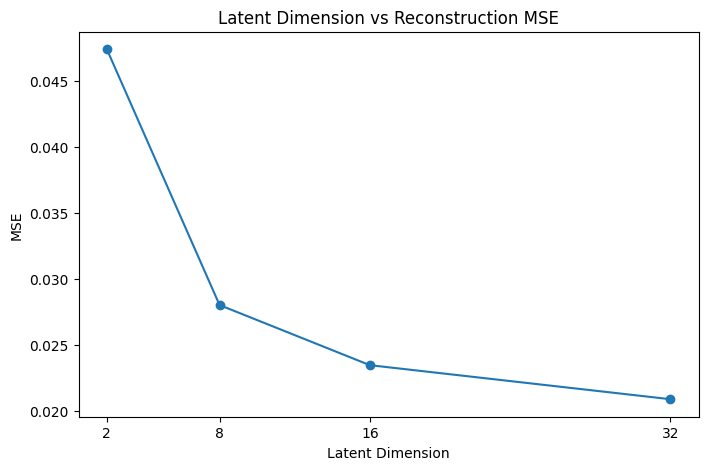

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    latent_dimensions,
    latent_dimension_table["MSE"],
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("MSE")
plt.title("Latent Dimension vs Reconstruction MSE")
plt.xticks(latent_dimensions)

plt.show()

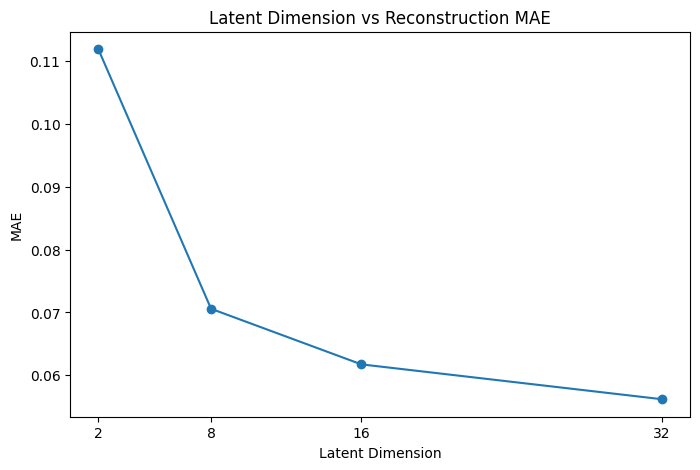

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    latent_dimensions,
    latent_dimension_table["MAE"],
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("MAE")
plt.title("Latent Dimension vs Reconstruction MAE")
plt.xticks(latent_dimensions)

plt.show()

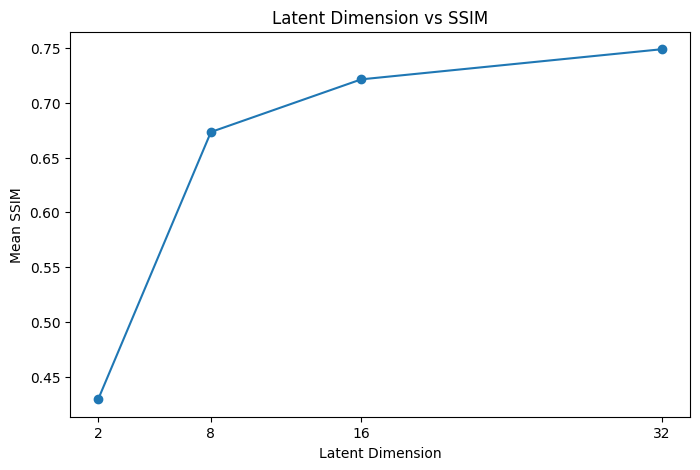

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    latent_dimensions,
    latent_dimension_table["SSIM"],
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Mean SSIM")
plt.title("Latent Dimension vs SSIM")
plt.xticks(latent_dimensions)

plt.show()

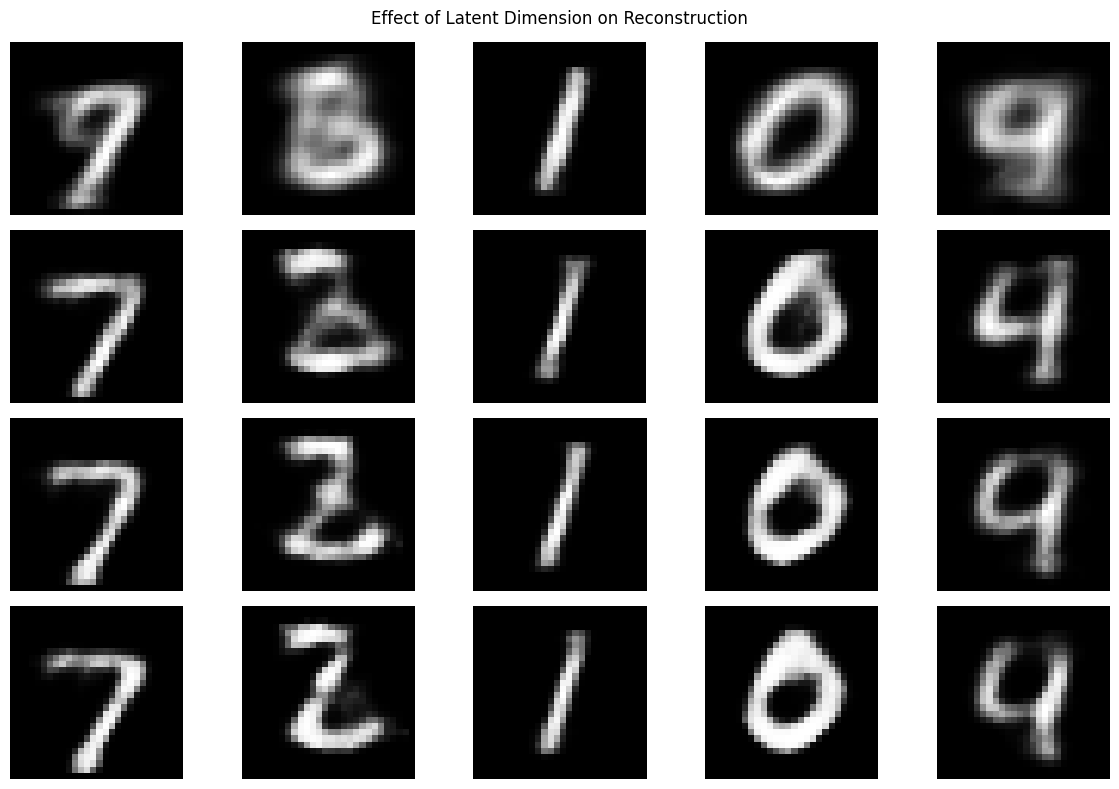

In [ ]:
plt.figure(figsize=(12, 8))

for row, latent_dim in enumerate(latent_dimensions):

    reconstructed = latent_results[
        latent_dim
    ]["Reconstructed"]

    for col in range(5):

        plt.subplot(
            len(latent_dimensions),
            5,
            row * 5 + col + 1
        )

        plt.imshow(
            reconstructed[col].squeeze(),
            cmap="gray"
        )

        plt.axis("off")

        if col == 0:
            plt.ylabel(
                f"Latent {latent_dim}"
            )

plt.suptitle(
    "Effect of Latent Dimension on Reconstruction"
)

plt.tight_layout()
plt.show()

In [ ]:
# Exercise 1
# CAE with latent dimensions 4, 8, 16 and 32

def build_cae_with_latent_dim(latent_dim):

    cae_input = keras.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    )(cae_input)

    x = layers.MaxPooling2D(
        (2, 2),
        padding="same"
    )(x)

    x = layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        (2, 2),
        padding="same"
    )(x)

    # Latent feature map
    latent = layers.Conv2D(
        latent_dim,
        (3, 3),
        activation="relu",
        padding="same"
    )(x)

    # Decoder
    x = layers.UpSampling2D((2, 2))(latent)

    x = layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.UpSampling2D((2, 2))(x)

    cae_output = layers.Conv2D(
        1,
        (3, 3),
        activation="sigmoid",
        padding="same"
    )(x)

    model = keras.Model(
        cae_input,
        cae_output
    )

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy"
    )

    return model

In [ ]:
cae_latent_dimensions = [4, 8, 16, 32]

cae_latent_results = {}

for latent_dim in cae_latent_dimensions:

    print("\n==============================")
    print("Latent Dimension:", latent_dim)
    print("==============================")

    model = build_cae_with_latent_dim(latent_dim)

    model.fit(
        x_train,
        x_train,
        epochs=20,
        batch_size=128,
        validation_data=(x_test, x_test),
        shuffle=True
    )

    reconstructed = model.predict(x_test)

    mse_value = np.mean(
        (x_test - reconstructed) ** 2
    )

    mae_value = np.mean(
        np.abs(x_test - reconstructed)
    )

    ssim_values = [
        ssim(
            x_test[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_test))
    ]

    ssim_value = np.mean(ssim_values)

    cae_latent_results[latent_dim] = {
        "MSE": mse_value,
        "MAE": mae_value,
        "SSIM": ssim_value,
        "Parameters": model.count_params(),
        "Reconstructed": reconstructed
    }

    print("MSE:", mse_value)
    print("MAE:", mae_value)
    print("SSIM:", ssim_value)
    print("Parameters:", model.count_params())


Latent Dimension: 4
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.3819 - val_loss: 0.1771
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1390 - val_loss: 0.1140
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1082 - val_loss: 0.1011
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0968 - val_loss: 0.0917
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0895 - val_loss: 0.0860
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0861 - val_loss: 0.0833
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0841 - val_loss: 0.0817
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0826 - val_loss: 0.0805
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0816 - val_loss: 0.0794
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0808 - val_loss: 0.0786
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0799 - val_loss: 0.0780
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step -

In [ ]:
cae_ex1_table = pd.DataFrame({
    "Latent Dimension": cae_latent_dimensions,
    "MSE": [
        cae_latent_results[d]["MSE"]
        for d in cae_latent_dimensions
    ],
    "MAE": [
        cae_latent_results[d]["MAE"]
        for d in cae_latent_dimensions
    ],
    "SSIM": [
        cae_latent_results[d]["SSIM"]
        for d in cae_latent_dimensions
    ],
    "Parameters": [
        cae_latent_results[d]["Parameters"]
        for d in cae_latent_dimensions
    ]
})

cae_ex1_table

,Latent Dimension,MSE,MAE,SSIM,Parameters
0,4,0.005387,0.022169,0.947936,22597
1,8,0.003740,0.018297,0.962672,26057
2,16,0.003175,0.016786,0.967971,32977
3,32,0.002787,0.015606,0.972008,46817


In [ ]:
# Exercise 2

# Gaussian noise
x_train_gaussian = add_gaussian_noise(
    x_train,
    sigma=0.2
)

x_test_gaussian = add_gaussian_noise(
    x_test,
    sigma=0.2
)

# Salt-and-pepper noise
x_train_sp = add_salt_pepper_noise(
    x_train,
    probability=0.20
)

x_test_sp = add_salt_pepper_noise(
    x_test,
    probability=0.20
)

In [ ]:
gaussian_model = build_cae_with_latent_dim(64)

salt_pepper_model = build_cae_with_latent_dim(64)

In [ ]:
gaussian_model.fit(
    x_train_gaussian,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(
        x_test_gaussian,
        x_test
    ),
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.2514 - val_loss: 0.1191
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1057 - val_loss: 0.0954
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0929 - val_loss: 0.0886
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0880 - val_loss: 0.0848
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0853 - val_loss: 0.0825
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0833 - val_loss: 0.0808
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0819 - val_loss: 0.0796
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0808 - val_loss: 0.0806
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0800 - val_loss: 0.0780
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0793 - val_loss: 0.0774
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0788 - val_loss: 0.0770
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0781 - val_l

In [ ]:
salt_pepper_model.fit(
    x_train_sp,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(
        x_test_sp,
        x_test
    ),
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.2718 - val_loss: 0.1392
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1238 - val_loss: 0.1123
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1070 - val_loss: 0.1030
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1013 - val_loss: 0.0982
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0977 - val_loss: 0.0951
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0950 - val_loss: 0.0935
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0932 - val_loss: 0.0913
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0916 - val_loss: 0.0899
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0905 - val_loss: 0.0893
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0893 - val_loss: 0.0888
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0885 - val_loss: 0.0881
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0879 - val_

In [ ]:
gaussian_reconstructed = gaussian_model.predict(
    x_test_gaussian
)

sp_reconstructed = salt_pepper_model.predict(
    x_test_sp
)

gaussian_mse, gaussian_mae, gaussian_ssim = calculate_metrics(
    x_test,
    gaussian_reconstructed
)

sp_mse, sp_mae, sp_ssim = calculate_metrics(
    x_test,
    sp_reconstructed
)

print("========== NOISE COMPARISON ==========")

print("\nGaussian Noise")
print("MSE :", gaussian_mse)
print("MAE :", gaussian_mae)
print("SSIM:", gaussian_ssim)

print("\nSalt-and-Pepper Noise")
print("MSE :", sp_mse)
print("MAE :", sp_mae)
print("SSIM:", sp_ssim)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
========== NOISE COMPARISON ==========

Gaussian Noise
MSE : 0.004635937
MAE : 0.021276623
SSIM: 0.9447845513629972

Salt-and-Pepper Noise
MSE : 0.0075070695
MAE : 0.027139645
SSIM: 0.9147874659893385


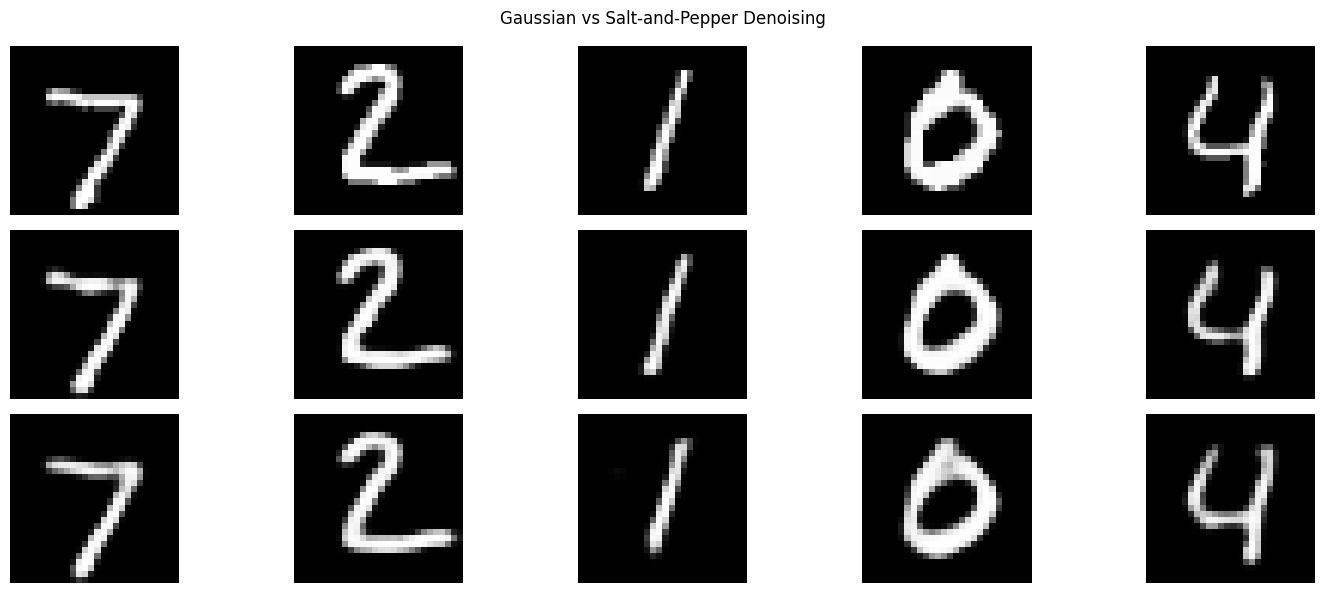

In [ ]:
plt.figure(figsize=(15, 6))

for i in range(5):

    # Original
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Gaussian
    plt.subplot(3, 5, 5 + i + 1)
    plt.imshow(
        gaussian_reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.axis("off")

    # Salt and pepper
    plt.subplot(3, 5, 10 + i + 1)
    plt.imshow(
        sp_reconstructed[i].squeeze(),
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle(
    "Gaussian vs Salt-and-Pepper Denoising"
)

plt.tight_layout()
plt.show()

In [ ]:
# Exercise 3

noise_levels = [0.1, 0.3]

ssim_results = {}

for sigma in noise_levels:

    print("\n============================")
    print("Gaussian Noise Sigma:", sigma)
    print("============================")

    noisy_train = add_gaussian_noise(
        x_train,
        sigma
    )

    noisy_test = add_gaussian_noise(
        x_test,
        sigma
    )

    model = build_cae_with_latent_dim(64)

    model.fit(
        noisy_train,
        x_train,
        epochs=20,
        batch_size=128,
        validation_data=(
            noisy_test,
            x_test
        ),
        shuffle=True
    )

    reconstructed = model.predict(
        noisy_test
    )

    _, _, ssim_value = calculate_metrics(
        x_test,
        reconstructed
    )

    ssim_results[sigma] = ssim_value

    print("SSIM:", ssim_value)


Gaussian Noise Sigma: 0.1
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.2139 - val_loss: 0.1041
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0936 - val_loss: 0.0865
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0848 - val_loss: 0.0806
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0807 - val_loss: 0.0805
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0788 - val_loss: 0.0762
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0771 - val_loss: 0.0750
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0758 - val_loss: 0.0737
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0750 - val_loss: 0.0738
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0743 - val_loss: 0.0725
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0736 - val_loss: 0.0725
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0732 - val_loss: 0.0730
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/

In [ ]:
print("\n========== SSIM COMPARISON ==========")

for sigma, value in ssim_results.items():
    print(
        f"Noise level {sigma}: SSIM = {value:.4f}"
    )


========== SSIM COMPARISON ==========
Noise level 0.1: SSIM = 0.9644
Noise level 0.3: SSIM = 0.9184


In [ ]:
# Exercise 4

def build_transpose_cae():

    model_input = keras.Input(
        shape=(28, 28, 1)
    )

    # Encoder
    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    )(model_input)

    x = layers.MaxPooling2D(
        2,
        padding="same"
    )(x)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        2,
        padding="same"
    )(x)

    # Latent
    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    )(x)

    # Decoder using Conv2DTranspose
    x = layers.Conv2DTranspose(
        32,
        3,
        strides=2,
        activation="relu",
        padding="same"
    )(x)

    x = layers.Conv2DTranspose(
        16,
        3,
        strides=2,
        activation="relu",
        padding="same"
    )(x)

    output = layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )(x)

    model = keras.Model(
        model_input,
        output
    )

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy"
    )

    return model

In [ ]:
transpose_cae = build_transpose_cae()

transpose_cae.fit(
    x_train,
    x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test, x_test),
    shuffle=True
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - loss: 0.3384 - val_loss: 0.1258
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1021 - val_loss: 0.0856
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0834 - val_loss: 0.0783
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0782 - val_loss: 0.0745
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0750 - val_loss: 0.0724
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0732 - val_loss: 0.0715
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0720 - val_loss: 0.0700
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0711 - val_loss: 0.0695
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0704 - val_loss: 0.0686
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0698 - val_loss: 0.0682
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0693 - val_loss: 0.0677
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0690 - val_l

In [ ]:
transpose_reconstructed = transpose_cae.predict(
    x_test
)

transpose_mse, transpose_mae, transpose_ssim = calculate_metrics(
    x_test,
    transpose_reconstructed
)

print("========== TRANSPOSED CONVOLUTION CAE ==========")
print("MSE :", transpose_mse)
print("MAE :", transpose_mae)
print("SSIM:", transpose_ssim)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
========== TRANSPOSED CONVOLUTION CAE ==========
MSE : 0.0021561203
MAE : 0.013673006
SSIM: 0.9778764268019706


In [ ]:
# Exercise 5

def build_vae(latent_dim):

    # Encoder
    encoder_input = keras.Input(
        shape=(28, 28, 1)
    )

    x = layers.Conv2D(
        32,
        3,
        activation="relu",
        strides=2,
        padding="same"
    )(encoder_input)

    x = layers.Conv2D(
        64,
        3,
        activation="relu",
        strides=2,
        padding="same"
    )(x)

    x = layers.Flatten()(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    z_mean = layers.Dense(
        latent_dim,
        name="z_mean"
    )(x)

    z_log_var = layers.Dense(
        latent_dim,
        name="z_log_var"
    )(x)

    def sampling(args):

        z_mean, z_log_var = args

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        sigma = tf.exp(
            0.5 * z_log_var
        )

        return z_mean + sigma * epsilon

    z = layers.Lambda(
        sampling
    )([z_mean, z_log_var])

    encoder = keras.Model(
        encoder_input,
        [z_mean, z_log_var, z]
    )

    # Decoder
    decoder_input = keras.Input(
        shape=(latent_dim,)
    )

    x = layers.Dense(
        7 * 7 * 64,
        activation="relu"
    )(decoder_input)

    x = layers.Reshape(
        (7, 7, 64)
    )(x)

    x = layers.Conv2DTranspose(
        64,
        3,
        strides=2,
        activation="relu",
        padding="same"
    )(x)

    x = layers.Conv2DTranspose(
        32,
        3,
        strides=2,
        activation="relu",
        padding="same"
    )(x)

    decoder_output = layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )(x)

    decoder = keras.Model(
        decoder_input,
        decoder_output
    )

    return encoder, decoder

In [ ]:
vae_results_ex5 = {}

for latent_dim in [2, 8]:

    print("\n==============================")
    print("VAE Latent Dimension:", latent_dim)
    print("==============================")

    encoder, decoder = build_vae(latent_dim)

    model = VAE(
        encoder,
        decoder
    )

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3)
    )

    model.fit(
        x_train,
        epochs=20,
        batch_size=128,
        validation_data=x_test
    )

    z_mean, z_log_var, z = encoder.predict(
        x_test
    )

    reconstructed = decoder.predict(z)

    mse_value = np.mean(
        (x_test - reconstructed) ** 2
    )

    mae_value = np.mean(
        np.abs(x_test - reconstructed)
    )

    ssim_values = [
        ssim(
            x_test[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_test))
    ]

    vae_results_ex5[latent_dim] = {
        "encoder": encoder,
        "decoder": decoder,
        "z_mean": z_mean,
        "reconstructed": reconstructed,
        "MSE": mse_value,
        "MAE": mae_value,
        "SSIM": np.mean(ssim_values)
    }

    print("MSE :", mse_value)
    print("MAE :", mae_value)
    print("SSIM:", np.mean(ssim_values))


VAE Latent Dimension: 2
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - kl_loss: 3.4361 - loss: 284.1375 - reconstruction_loss: 280.7013 - val_kl_loss: 3.2643 - val_loss: 194.1125 - val_reconstruction_loss: 190.8482
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.2326 - loss: 197.1244 - reconstruction_loss: 193.8918 - val_kl_loss: 3.8296 - val_loss: 180.1840 - val_reconstruction_loss: 176.3544
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.9652 - loss: 185.2105 - reconstruction_loss: 181.2452 - val_kl_loss: 4.2112 - val_loss: 175.9276 - val_reconstruction_loss: 171.7164
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.1837 - loss: 181.3845 - reconstruction_loss: 177.2007 - val_kl_loss: 4.1379 - val_loss: 174.0459 - val_reconstruction_loss: 169.9080
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 4.3044 - loss: 178.8088 - reconstruction_loss: 174.5044 - val_kl_loss: 4.2308 - val_loss: 173.3542 - val_reconstruction_loss: 16

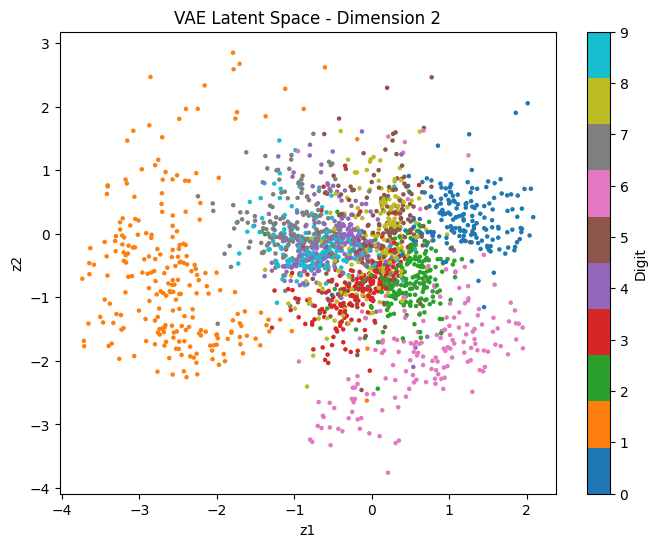

In [ ]:
z_mean_2 = vae_results_ex5[2]["z_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    z_mean_2[:, 0],
    z_mean_2[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE Latent Space - Dimension 2")
plt.colorbar(label="Digit")

plt.show()

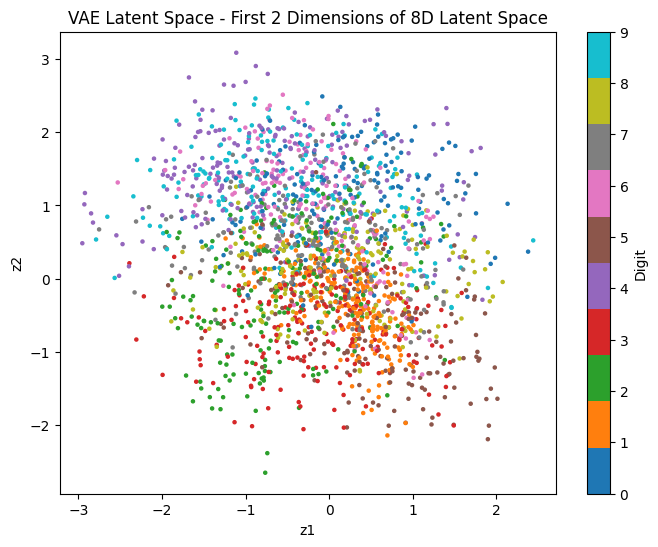

In [ ]:
z_mean_8 = vae_results_ex5[8]["z_mean"]

plt.figure(figsize=(8, 6))

plt.scatter(
    z_mean_8[:, 0],
    z_mean_8[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE Latent Space - First 2 Dimensions of 8D Latent Space")
plt.colorbar(label="Digit")

plt.show()

In [ ]:
class BetaVAE(keras.Model):

    def __init__(
        self,
        encoder,
        decoder,
        beta=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    # IMPORTANT: This was missing
    def call(self, inputs, training=False):

        z_mean, z_log_var, z = self.encoder(
            inputs,
            training=training
        )

        reconstruction = self.decoder(
            z,
            training=training
        )

        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                data,
                training=True
            )

            reconstruction = self.decoder(
                z,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # β controls the contribution of KL loss
            total_loss = (
                reconstruction_loss
                + self.beta * kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.trainable_weights
            )
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(
            data,
            training=False
        )

        reconstruction = self.decoder(
            z,
            training=False
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

In [ ]:
beta_values = [0.1, 1.0, 5.0]

beta_results = {}

for beta in beta_values:

    print("\n============================")
    print("Beta =", beta)
    print("============================")

    encoder, decoder = build_vae(2)

    beta_vae = BetaVAE(
        encoder,
        decoder,
        beta=beta
    )

    beta_vae.compile(
        optimizer=keras.optimizers.Adam(1e-3)
    )

    beta_vae.fit(
        x_train,
        epochs=20,
        batch_size=128,
        validation_data=x_test
    )

    z_mean, z_log_var, z = encoder.predict(
        x_test
    )

    reconstructed = decoder.predict(z)

    mse_value = np.mean(
        (x_test - reconstructed) ** 2
    )

    beta_results[beta] = {
        "MSE": mse_value,
        "encoder": encoder,
        "decoder": decoder
    }

    print("Test MSE:", mse_value)


Beta = 0.1
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - kl_loss: 16.9539 - loss: 292.9561 - reconstruction_loss: 291.2608 - val_kl_loss: 19.8269 - val_loss: 193.5181 - val_reconstruction_loss: 191.5354
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 16.5316 - loss: 202.1446 - reconstruction_loss: 200.4914 - val_kl_loss: 18.0960 - val_loss: 187.7098 - val_reconstruction_loss: 185.9002
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 14.2988 - loss: 195.2720 - reconstruction_loss: 193.8421 - val_kl_loss: 12.6661 - val_loss: 182.3969 - val_reconstruction_loss: 181.1303
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 12.7096 - loss: 183.7223 - reconstruction_loss: 182.4514 - val_kl_loss: 11.4895 - val_loss: 170.9580 - val_reconstruction_loss: 169.8090
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 12.3265 - loss: 172.7431 - reconstruction_loss: 171.5105 - val_kl_loss: 10.4833 - val_loss: 165.9590 - val_reconstruction_loss: 164.9

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step


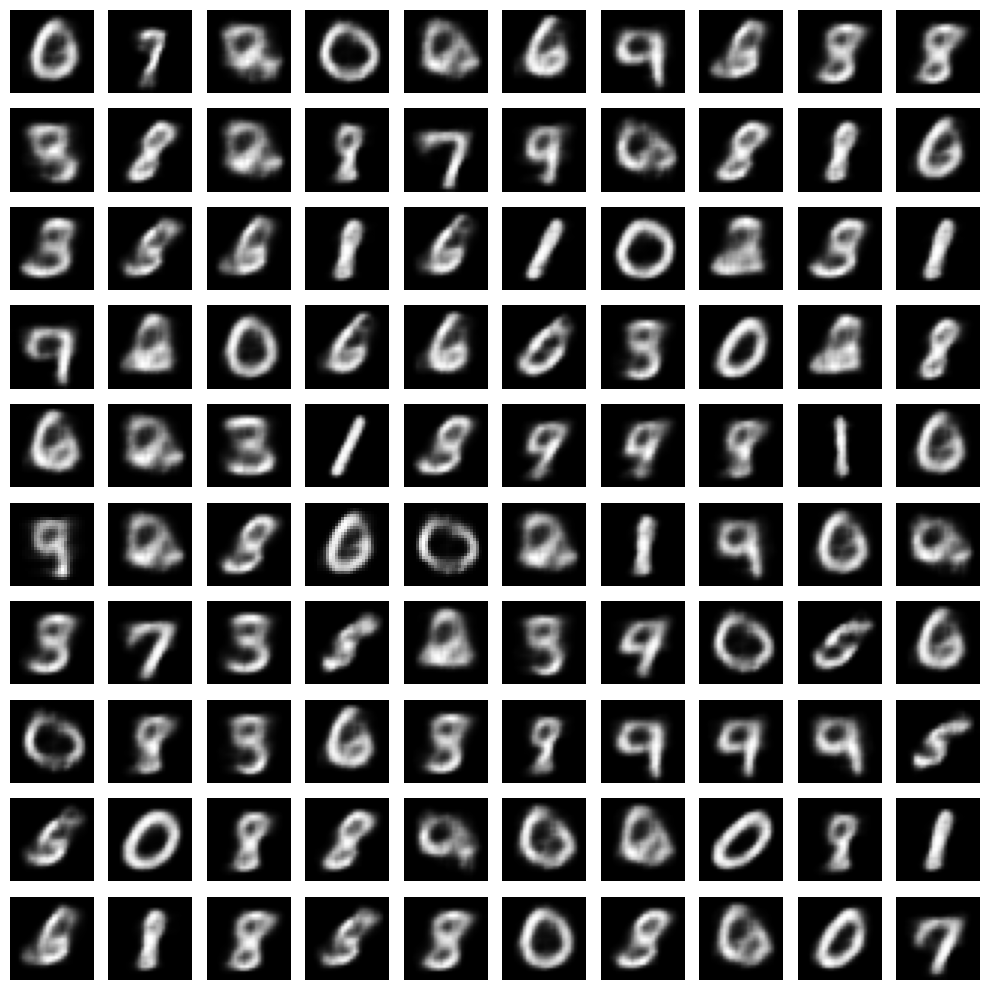

In [ ]:
# Generate 100 random latent vectors
large_latent_vectors = np.random.normal(
    size=(100, 2)
)

# Decode them
large_generated_images = decoder_vae.predict(
    large_latent_vectors
)

# Display a 10 x 10 grid
plt.figure(figsize=(10, 10))

for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(large_generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

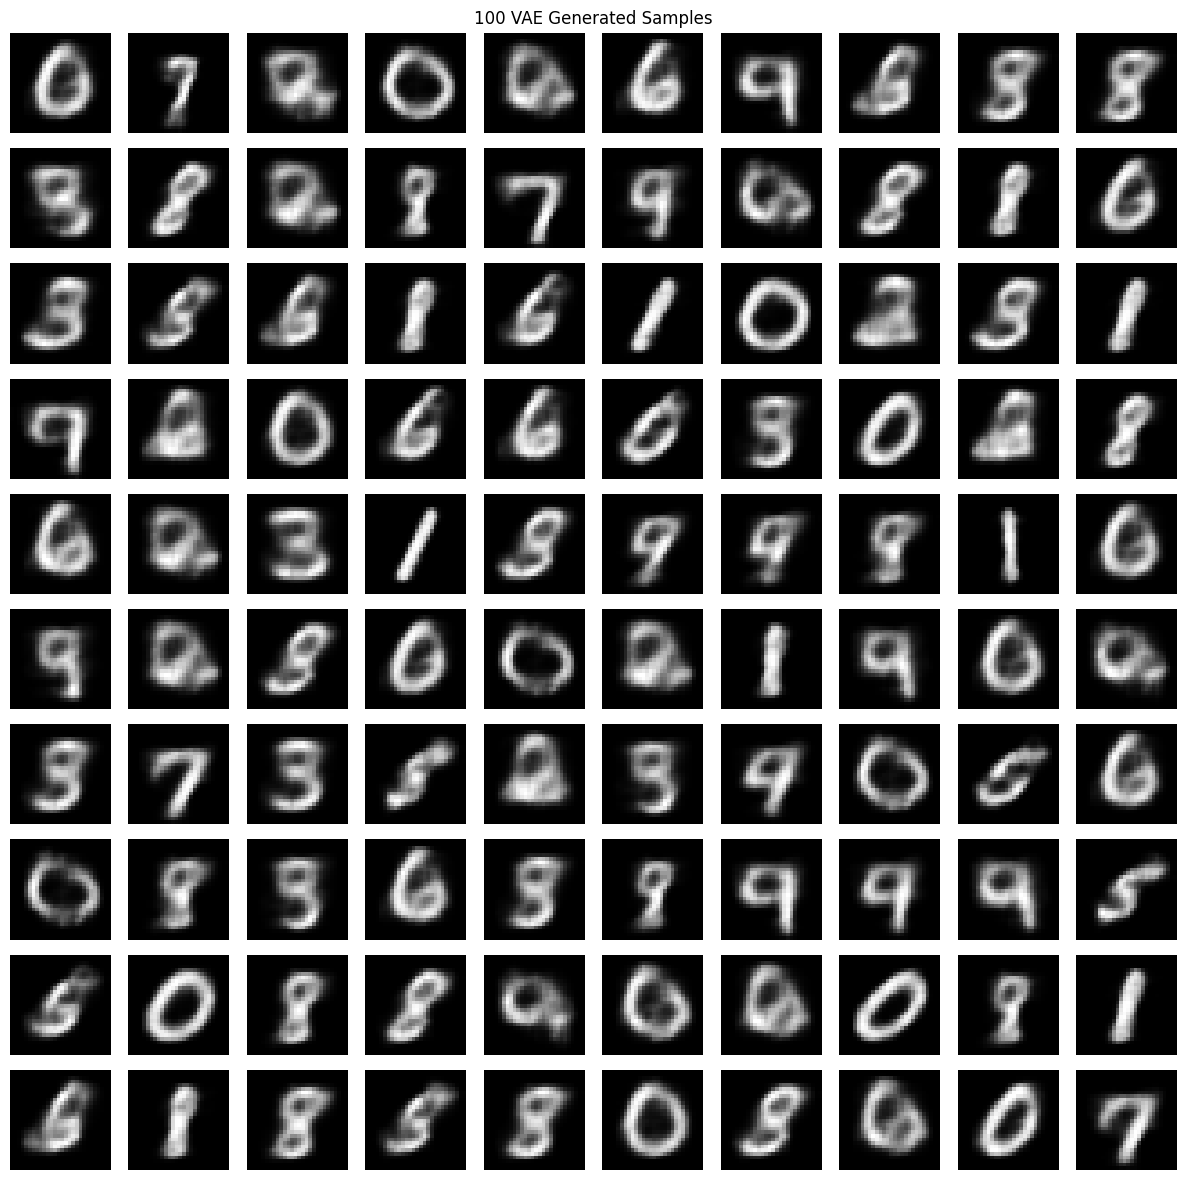

In [ ]:
plt.figure(figsize=(12, 12))

for i in range(100):

    plt.subplot(10, 10, i + 1)

    plt.imshow(
        large_generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "100 VAE Generated Samples"
)

plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


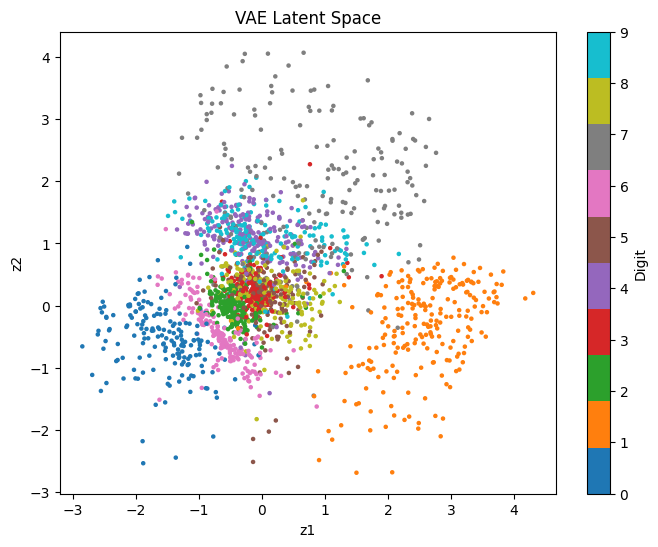

In [ ]:
# Exercise 8

z_mean_test, z_log_var_test, z_test = encoder_vae.predict(
    x_test
)

plt.figure(figsize=(8, 6))

plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=5
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE Latent Space")

plt.colorbar(label="Digit")

plt.show()

In [ ]:
# Find examples of two different digits

index_A = np.where(y_test == 0)[0][0]
index_B = np.where(y_test == 1)[0][0]

zA = z_mean_test[index_A]
zB = z_mean_test[index_B]

print("Digit A:", y_test[index_A])
print("Digit B:", y_test[index_B])

Digit A: 0
Digit B: 1


In [ ]:
alphas = np.linspace(
    0,
    1,
    11
)

interpolated_latents = np.array([
    (1 - alpha) * zA + alpha * zB
    for alpha in alphas
])

interpolated_images = decoder_vae.predict(
    interpolated_latents
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


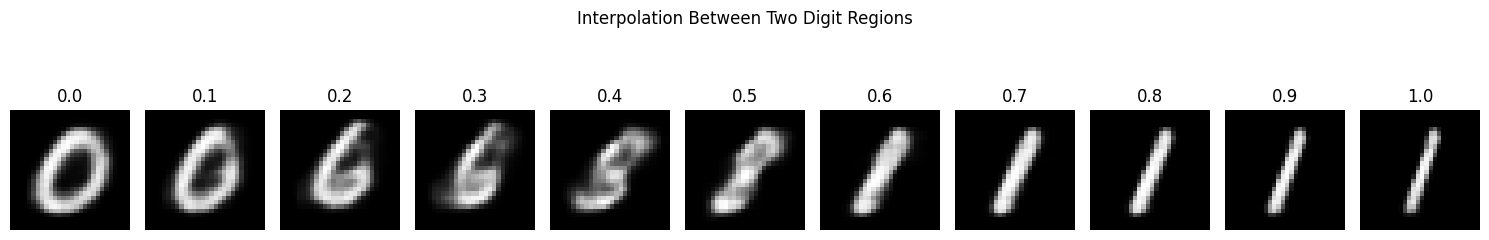

In [ ]:
plt.figure(figsize=(15, 3))

for i in range(11):

    plt.subplot(
        1,
        11,
        i + 1
    )

    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    plt.title(
        f"{alphas[i]:.1f}"
    )

plt.suptitle(
    "Interpolation Between Two Digit Regions"
)

plt.tight_layout()
plt.show()